# Voxel Allegiance: Visualization & QC

NIfTI map generation, slice overlays, and diagnostic outputs.

**Standalone** — all data loading and computation is included.

## Setup & Configuration

In [1]:
import os
import sys
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import (processed_dir, skip_subs, get_sessions,
                           is_patient, get_sub_info, _load_csv)

# ── Category definitions ──────────────────────────────────────────────────────
CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {
    'face':   '#E74C3C',
    'house':  '#3498DB',
    'object': '#2ECC71',
    'word':   '#F39C12',
    'none':   '#BDC3C7',
}

RAW_BETA_COPES = {'face': 15, 'house': 16, 'object': 17, 'word': 18}
CAT_VS_ALL_COPES = {'face': 6, 'house': 7, 'object': 8, 'word': 9}
DIFFERENTIAL_COPES = {'face': 1, 'house': 2, 'object': 3, 'word': 4}

ALLEGIANCE_COPE_SET = 'cat_vs_all'
WTA_THRESHOLD = 0

PRE_SURGERY_SESSIONS = {
    'sub-021': ['01'], 'sub-045': ['01'], 'sub-047': ['01'], 'sub-049': ['01'],
    'sub-070': ['01'], 'sub-073': ['01'], 'sub-081': ['01'], 'sub-086': ['01'],
}
EXCLUDE_SUBS = ['OTC108', 'control083', 'control085', 'OTC017', 'control027']

## Helper Functions

In [2]:
def get_cope_map():
    if ALLEGIANCE_COPE_SET == 'raw_beta':
        return RAW_BETA_COPES
    elif ALLEGIANCE_COPE_SET == 'cat_vs_all':
        return CAT_VS_ALL_COPES
    elif ALLEGIANCE_COPE_SET == 'differential':
        return DIFFERENTIAL_COPES
    else:
        raise ValueError(f"Unknown cope set: {ALLEGIANCE_COPE_SET}")


def load_subjects():
    df = _load_csv()
    subjects = {}
    for sub_clean in sorted(df['sub_clean'].unique()):
        if sub_clean in skip_subs:
            continue
        sid = f'sub-{sub_clean}'
        sessions = get_sessions(sub_clean)
        base = os.path.join(processed_dir, sid)
        if not sessions or not os.path.exists(base):
            continue
        info = get_sub_info(sub_clean, sessions[0])
        pt = is_patient(sub_clean)
        intact = info.get('intact_hemi', '')
        code = f"{info.get('group', '')}{sub_clean}"
        if code in EXCLUDE_SUBS:
            continue
        actual_first_ses = f'{sessions[0]:02d}'
        post_sessions = []
        for s in sessions:
            ses_str = f'{s:02d}'
            if sid in PRE_SURGERY_SESSIONS and ses_str in PRE_SURGERY_SESSIONS[sid]:
                continue
            post_sessions.append(ses_str)
        if not post_sessions:
            continue
        subjects[sid] = {
            'code': code, 'sessions': post_sessions,
            'actual_first_ses': actual_first_ses,
            'hemi': ('l' if intact == 'left' else 'r') if pt else None,
            'group': info.get('group', 'unknown'),
            'patient_status': info.get('group', 'unknown'),
            'intact_hemi': intact,
            'surgery_side': ('right' if intact == 'left' else 'left') if pt else 'na',
        }
    return subjects


def get_votc_mask(sub_id, actual_first_ses, hemi):
    roi_dir = os.path.join(processed_dir, sub_id, f'ses-{actual_first_ses}', 'ROIs')
    combined, affine = None, None
    for cat in CATEGORIES:
        mask_path = os.path.join(roi_dir, f'{hemi}_{cat}_searchmask.nii.gz')
        if os.path.exists(mask_path):
            img = nib.load(mask_path)
            data = img.get_fdata() > 0
            if combined is None:
                combined = data.copy(); affine = img.affine
            else:
                combined = combined | data
    if combined is None:
        ventral_path = os.path.join(processed_dir, sub_id, f'ses-{actual_first_ses}',
                                     'derivatives', 'rois', f'{hemi}Ventral.nii.gz')
        if os.path.exists(ventral_path):
            img = nib.load(ventral_path)
            combined = img.get_fdata() > 0; affine = img.affine
    return combined, affine


def load_category_betas(sub_id, session, actual_first_ses, mask, cope_map):
    feat_dir = os.path.join(processed_dir, sub_id, f'ses-{session}',
                            'derivatives', 'fsl', 'loc', 'HighLevel.gfeat')
    if ALLEGIANCE_COPE_SET == 'raw_beta':
        stat_file = 'cope1.nii.gz' if session == actual_first_ses else f'cope1_ses{actual_first_ses}.nii.gz'
    else:
        stat_file = 'zstat1.nii.gz' if session == actual_first_ses else f'zstat1_ses{actual_first_ses}.nii.gz'
    betas = {}
    for cat, cope_num in cope_map.items():
        fpath = os.path.join(feat_dir, f'cope{cope_num}.feat', 'stats', stat_file)
        if not os.path.exists(fpath):
            return None
        betas[cat] = nib.load(fpath).get_fdata()[mask]
    return betas


def compute_wta(betas, threshold=0):
    beta_matrix = np.column_stack([betas[cat] for cat in CATEGORIES])
    max_vals = np.max(beta_matrix, axis=1)
    winners = np.argmax(beta_matrix, axis=1)
    sorted_betas = np.sort(beta_matrix, axis=1)
    margin = sorted_betas[:, -1] - sorted_betas[:, -2]
    if threshold > 0:
        winners[max_vals < threshold] = -1
    return winners, margin, max_vals


def compute_transition_matrix(winners_t1, winners_t2, n_categories=4):
    valid = (winners_t1 >= 0) & (winners_t2 >= 0)
    w1, w2 = winners_t1[valid], winners_t2[valid]
    trans = np.zeros((n_categories, n_categories), dtype=int)
    for i in range(len(w1)):
        trans[w1[i], w2[i]] += 1
    row_sums = trans.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    trans_pct = trans / row_sums * 100
    total_valid = valid.sum()
    retention = np.diag(trans).sum() / total_valid if total_valid > 0 else np.nan
    return trans, trans_pct, retention

## Load Data & Compute WTA + Transitions

In [3]:
# ── Load subjects ─────────────────────────────────────────────────────────────
subjects = load_subjects()
long_subs = {sid: info for sid, info in subjects.items() if len(info['sessions']) >= 2}
cope_map = get_cope_map()
threshold = WTA_THRESHOLD if ALLEGIANCE_COPE_SET == 'raw_beta' else 1.96
print(f"Loaded {len(subjects)} subjects ({len(long_subs)} longitudinal)")

# ── Compute WTA for all subjects, all sessions ───────────────────────────────
# (needed for NIfTI writing)

wta_nifti_dir = os.path.join(processed_dir, 'group_results', 'wta_maps')
os.makedirs(wta_nifti_dir, exist_ok=True)

print("Computing WTA for all subjects...")
wta_count = 0
for sid, info in subjects.items():
    actual_first = info['actual_first_ses']
    hemis = [info['hemi']] if info['patient_status'] == 'OTC' else ['l', 'r']
    for ses in info['sessions']:
        for h in hemis:
            mask, affine = get_votc_mask(sid, actual_first, h)
            if mask is None or int(mask.sum()) == 0:
                continue
            betas = load_category_betas(sid, ses, actual_first, mask, cope_map)
            if betas is None:
                continue
            wta_count += 1

print(f"  {wta_count} subject-session-hemisphere entries to process")

# ── Compute transitions for longitudinal subjects ────────────────────────────

transition_results = {}

for sid, info in long_subs.items():
    sessions = info['sessions']
    t1_ses, t2_ses = sessions[0], sessions[-1]
    actual_first = info['actual_first_ses']
    hemis = [info['hemi']] if info['patient_status'] == 'OTC' else ['l', 'r']

    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None:
            continue
        betas_t1 = load_category_betas(sid, t1_ses, actual_first, mask, cope_map)
        betas_t2 = load_category_betas(sid, t2_ses, actual_first, mask, cope_map)
        if betas_t1 is None or betas_t2 is None:
            continue

        winners_t1, margin_t1, _ = compute_wta(betas_t1, threshold)
        winners_t2, margin_t2, _ = compute_wta(betas_t2, threshold)
        trans, trans_pct, retention = compute_transition_matrix(winners_t1, winners_t2)

        transition_results[(sid, h)] = {
            'trans_counts': trans, 'trans_pct': trans_pct, 'retention': retention,
            'winners_t1': winners_t1, 'winners_t2': winners_t2,
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'),
            't1_ses': t1_ses, 't2_ses': t2_ses,
        }

print(f"Computed transitions for {len(transition_results)} subject-hemisphere entries")

Loaded 46 subjects (16 longitudinal)
Computing WTA for all subjects...
  109 subject-session-hemisphere entries to process
Computed transitions for 27 subject-hemisphere entries


## 1. Write WTA Category Maps as NIfTI

In [4]:
# ── Write WTA category maps as NIfTI volumes ─────────────────────────────────
# Values: 1=face, 2=house, 3=object, 4=word, 0=unassigned

for sid, info in subjects.items():
    actual_first = info['actual_first_ses']
    hemis = [info['hemi']] if info['patient_status'] == 'OTC' else ['l', 'r']

    for ses in info['sessions']:
        for h in hemis:
            mask, affine = get_votc_mask(sid, actual_first, h)
            if mask is None:
                continue

            betas = load_category_betas(sid, ses, actual_first, mask, cope_map)
            if betas is None:
                continue

            winners, margin, max_vals = compute_wta(betas, threshold)

            brain_shape = mask.shape
            wta_vol = np.zeros(brain_shape, dtype=np.float32)
            margin_vol = np.zeros(brain_shape, dtype=np.float32)

            voxel_coords = np.where(mask)
            for idx in range(len(winners)):
                cat_val = winners[idx] + 1 if winners[idx] >= 0 else 0
                wta_vol[voxel_coords[0][idx], voxel_coords[1][idx], voxel_coords[2][idx]] = cat_val
                margin_vol[voxel_coords[0][idx], voxel_coords[1][idx], voxel_coords[2][idx]] = margin[idx]

            tag = f'{sid}_ses-{ses}_{h}h'
            nib.save(nib.Nifti1Image(wta_vol, affine),
                     os.path.join(wta_nifti_dir, f'{tag}_wta.nii.gz'))
            nib.save(nib.Nifti1Image(margin_vol, affine),
                     os.path.join(wta_nifti_dir, f'{tag}_margin.nii.gz'))

print(f"Saved WTA NIfTI volumes to: {wta_nifti_dir}")
print("Values: 1=face, 2=house, 3=object, 4=word, 0=unassigned")

Saved WTA NIfTI volumes to: /user_data/csimmon2/sym_pt/group_results/wta_maps
Values: 1=face, 2=house, 3=object, 4=word, 0=unassigned


## 2. Nilearn Ventral View: WTA Maps per Patient

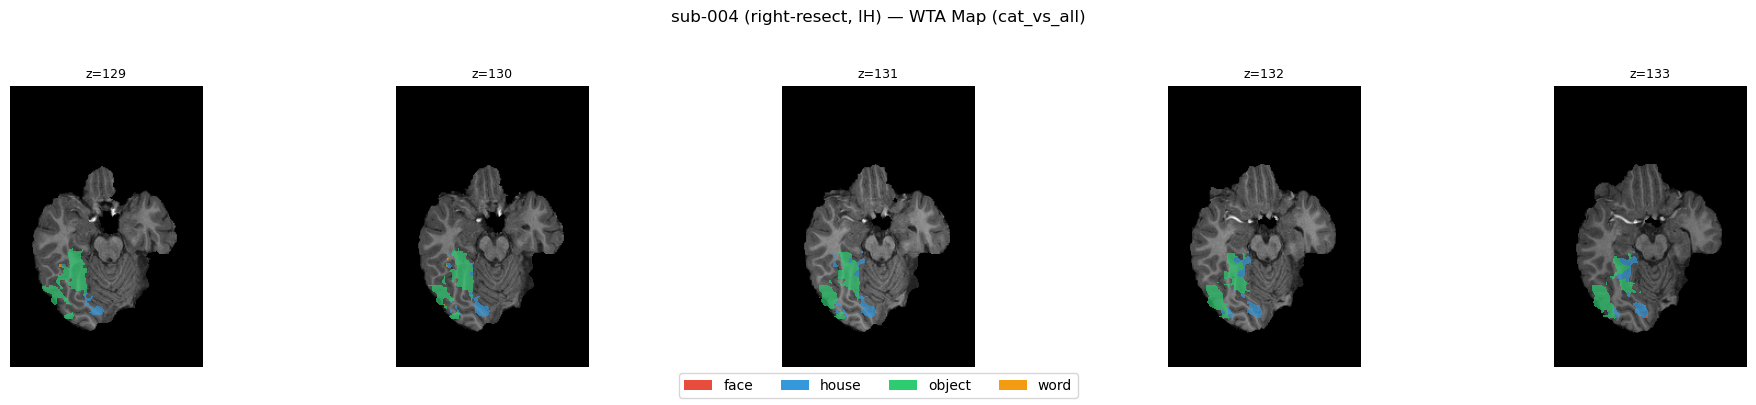

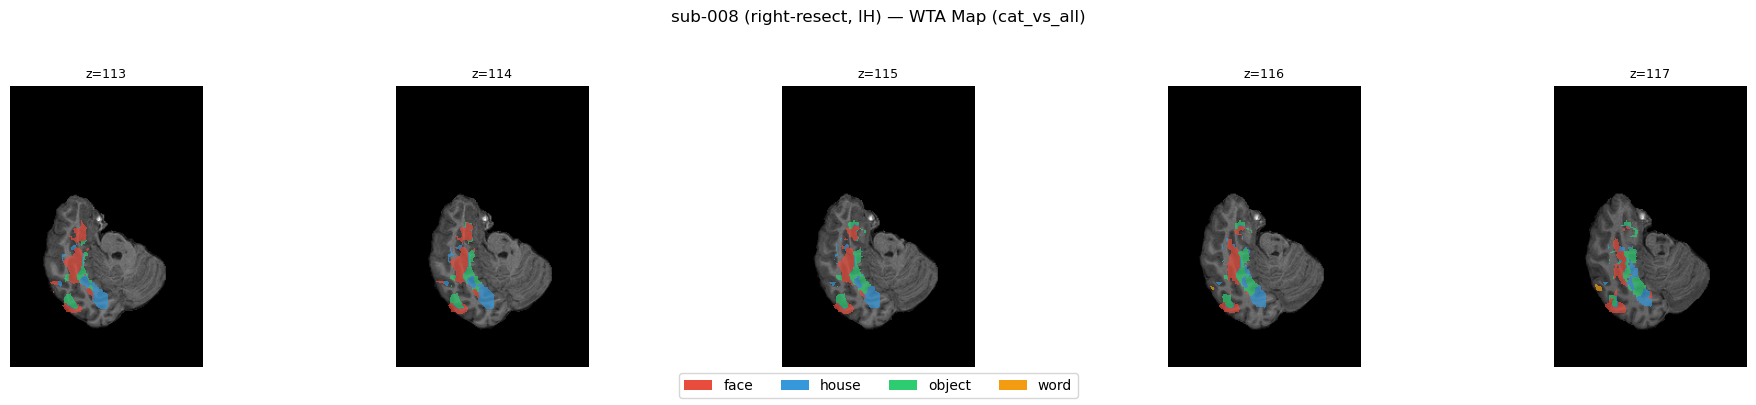

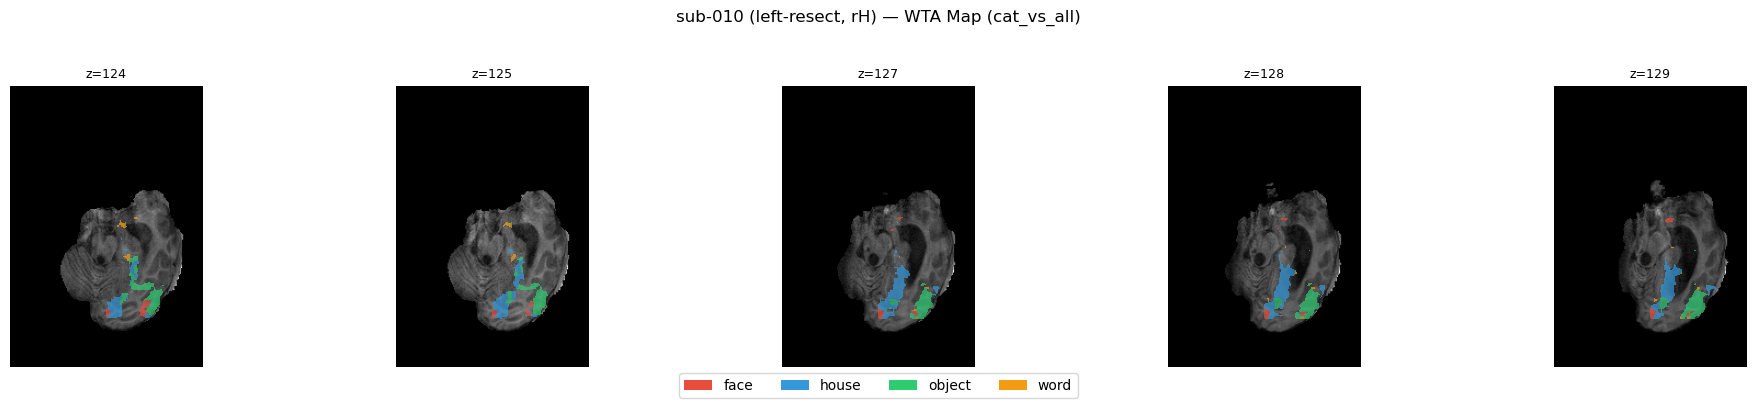

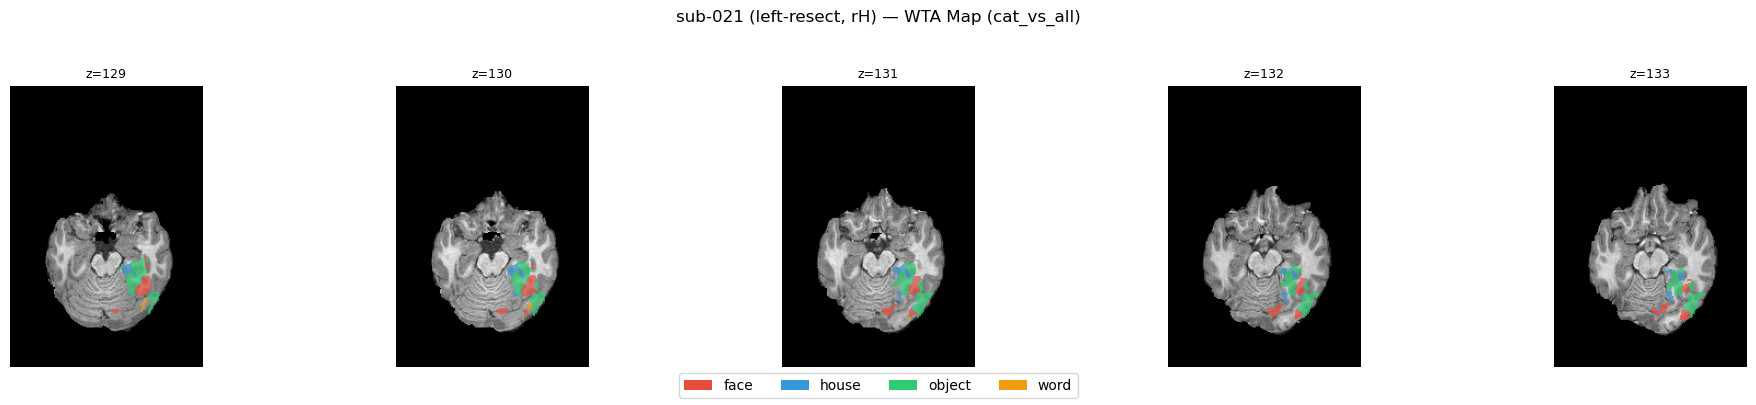

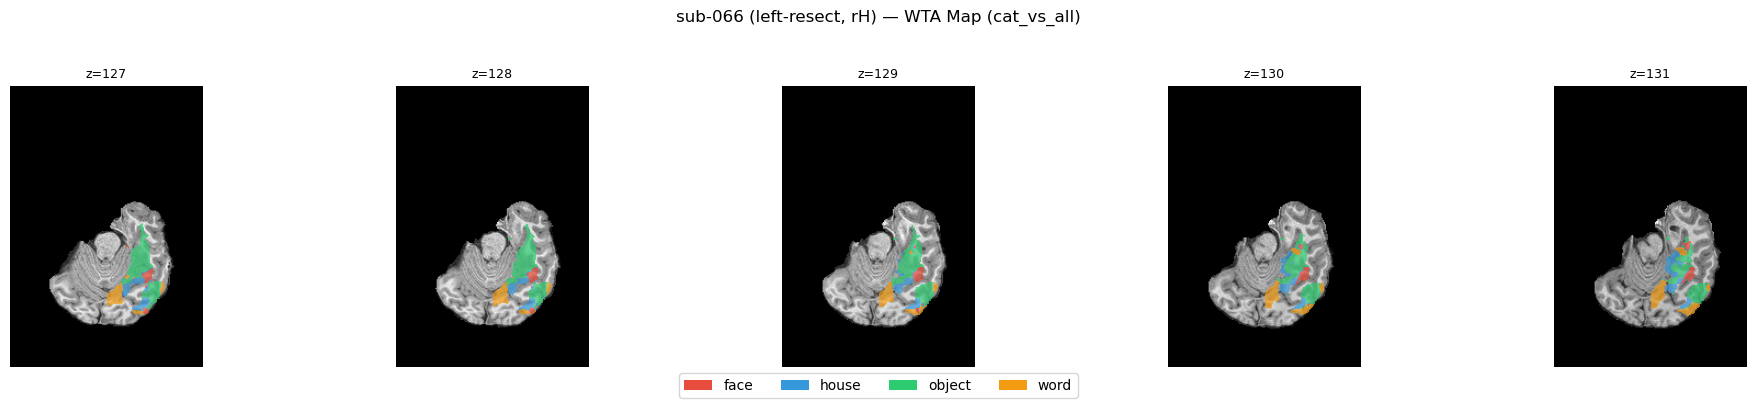

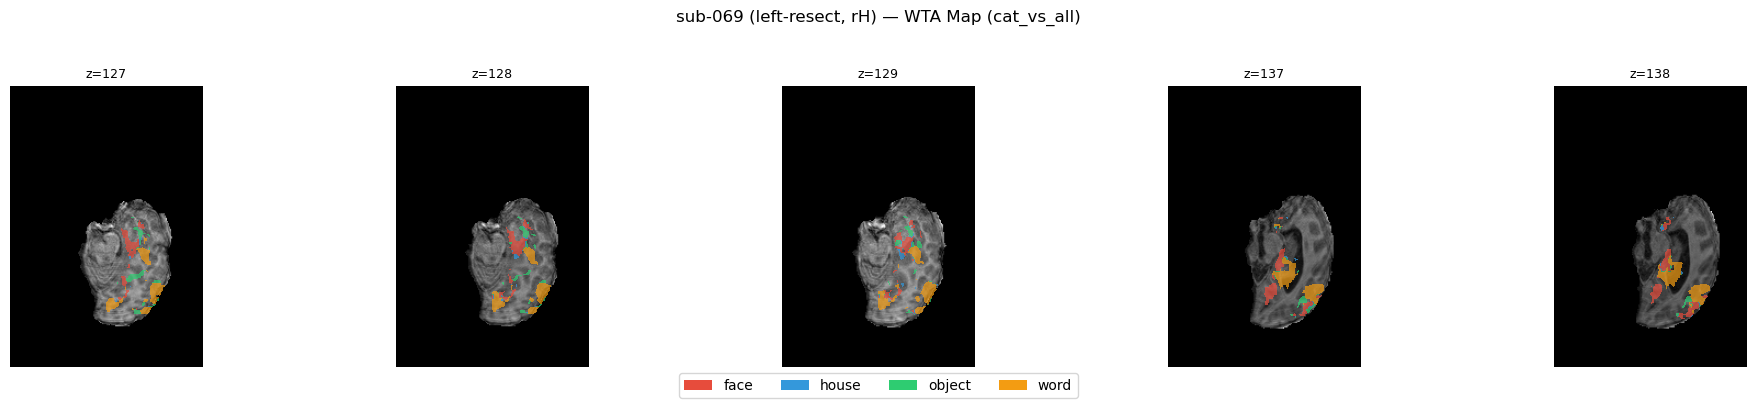

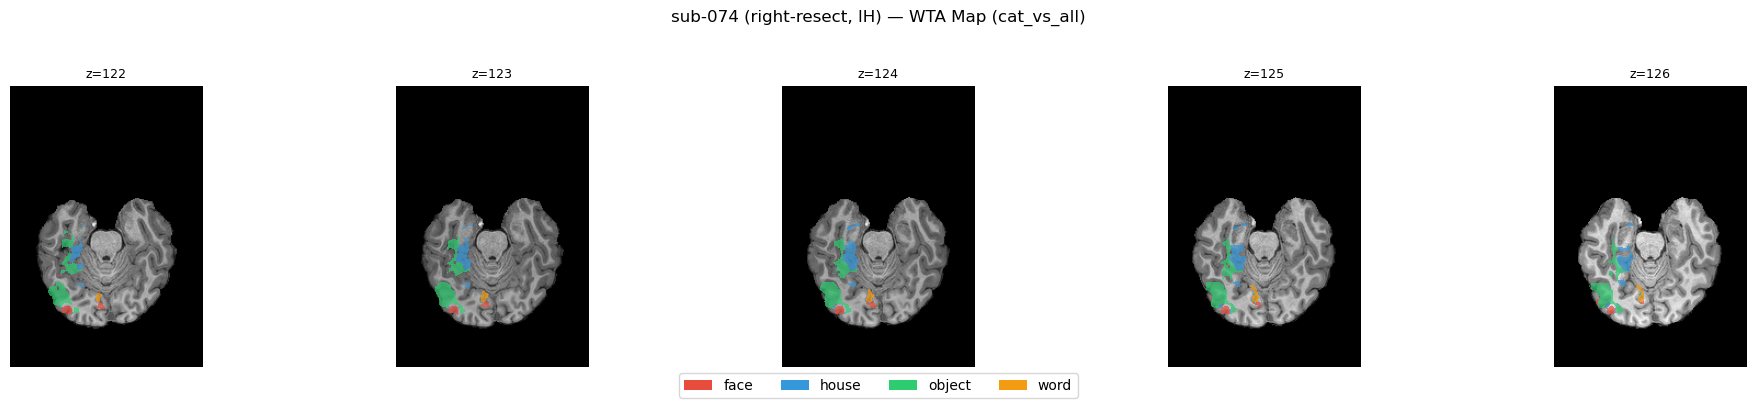

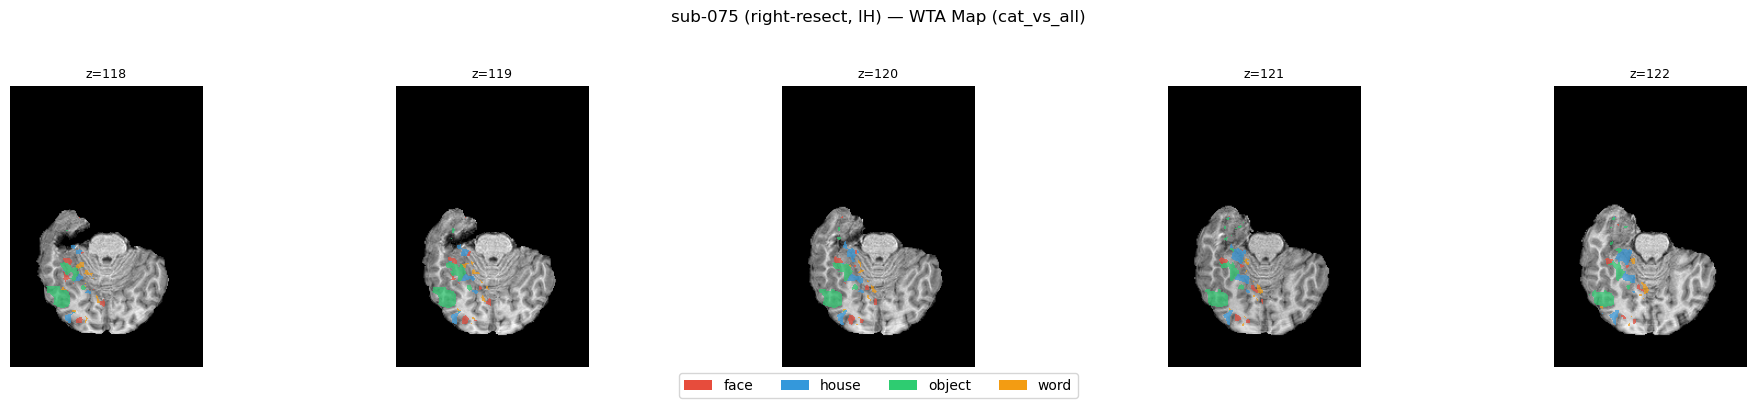

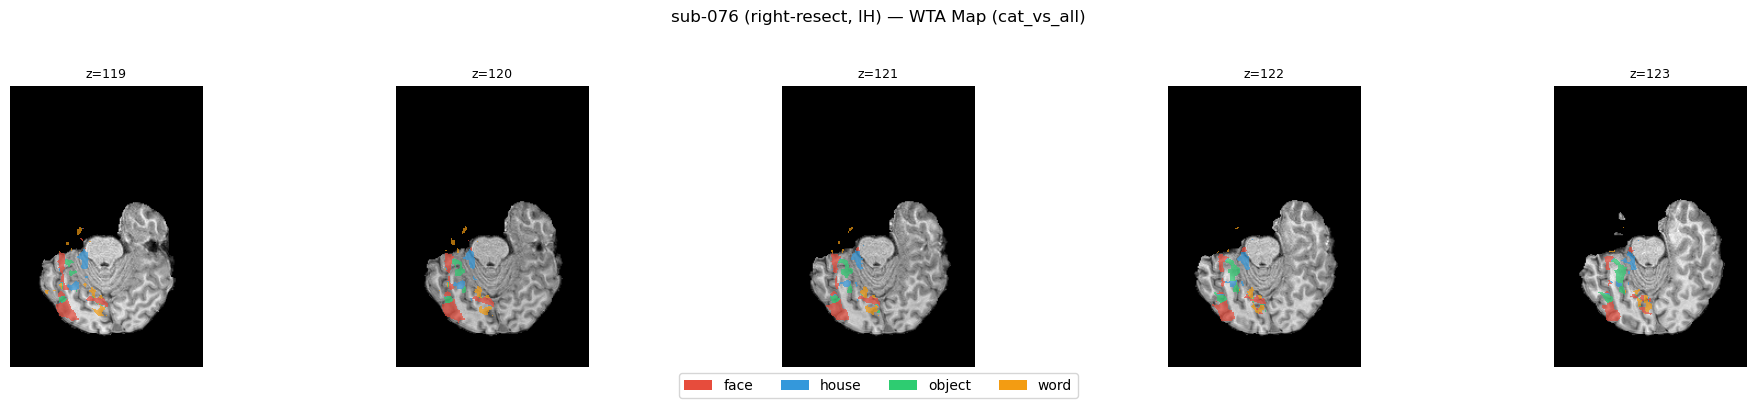

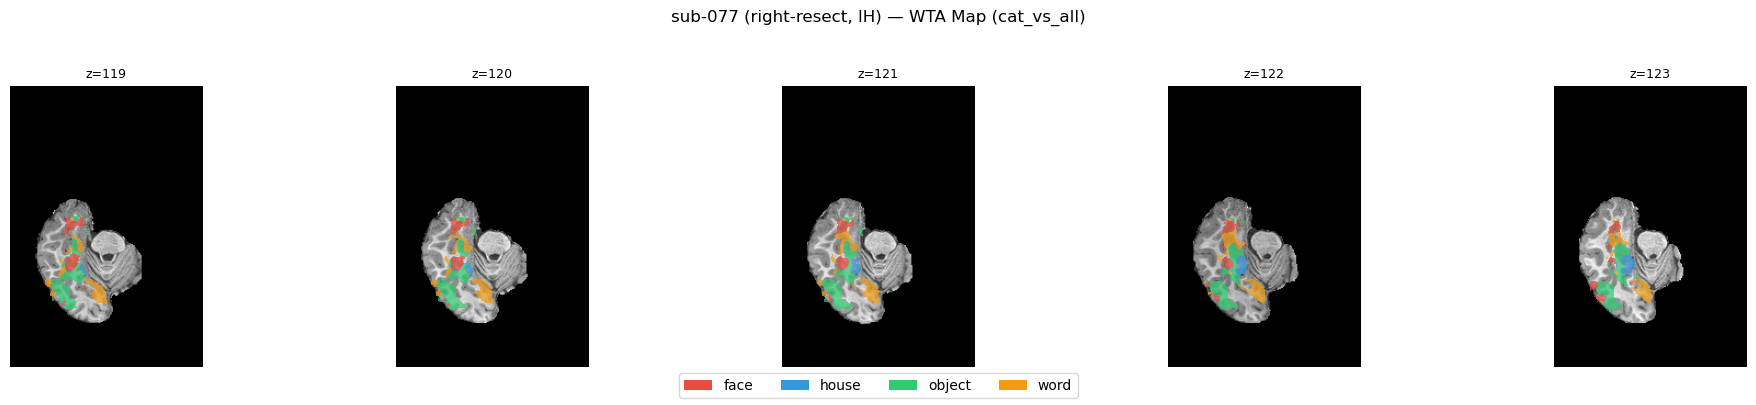

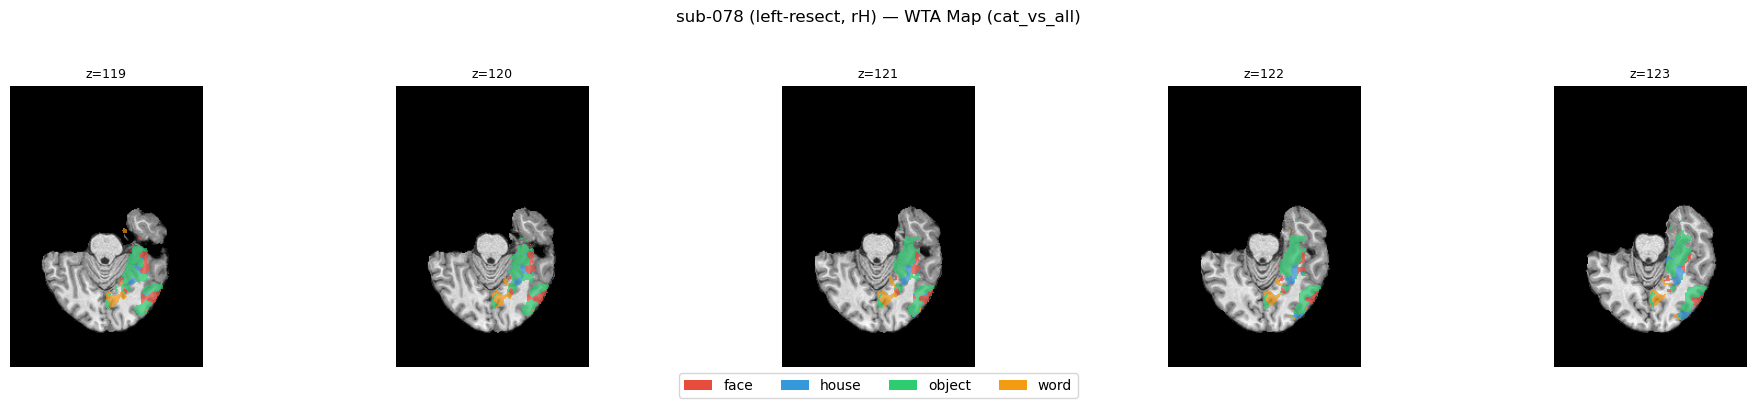

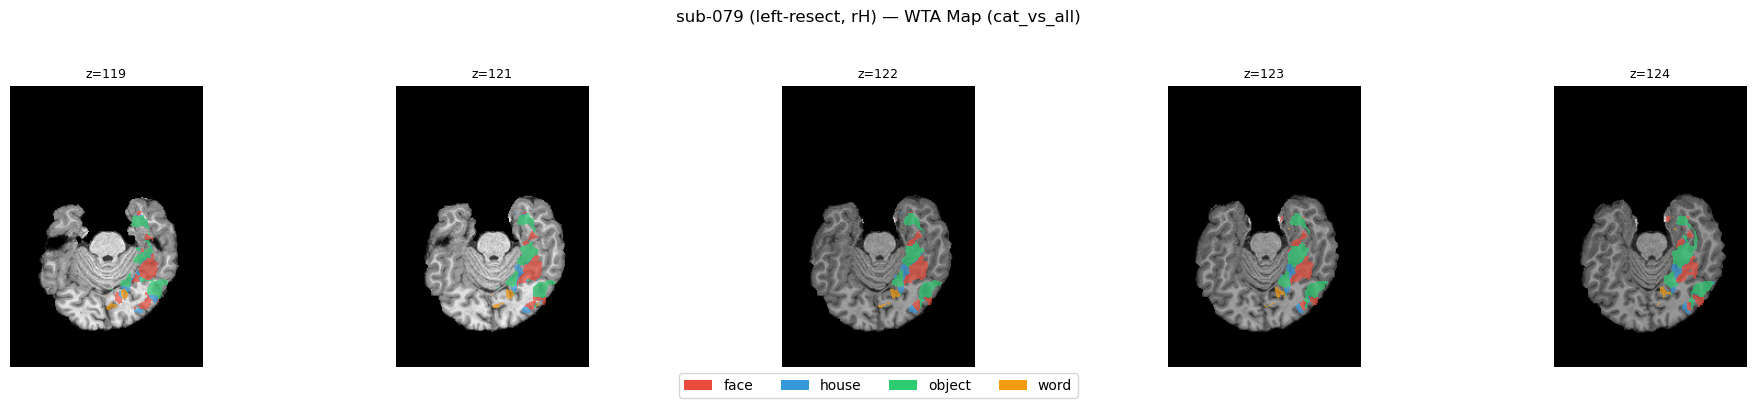

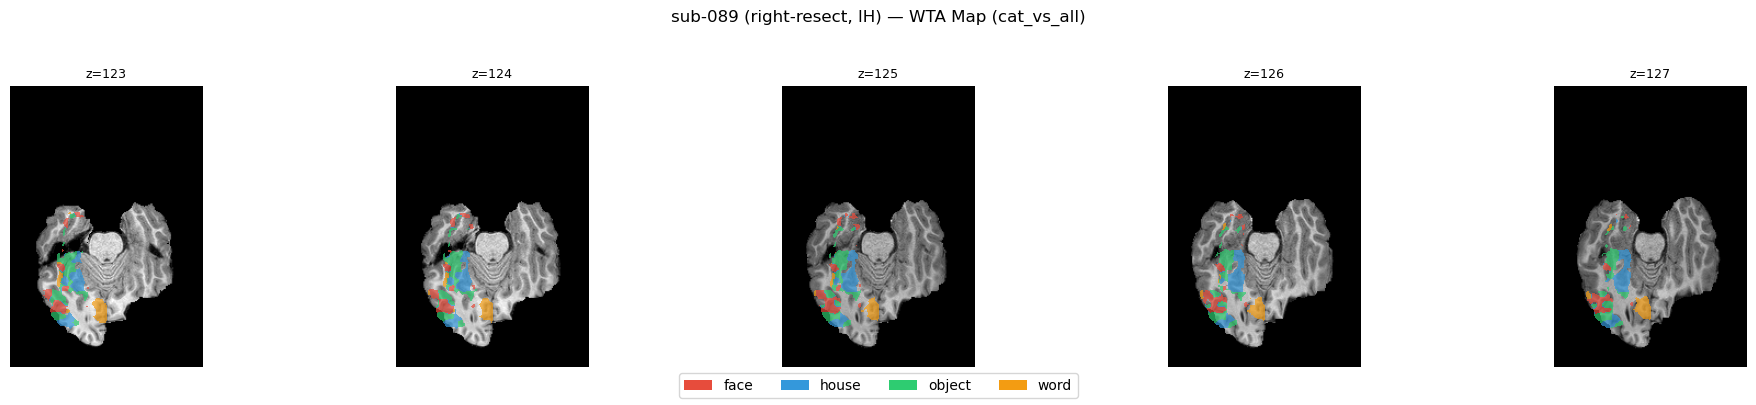

  SKIP sub-090: missing files


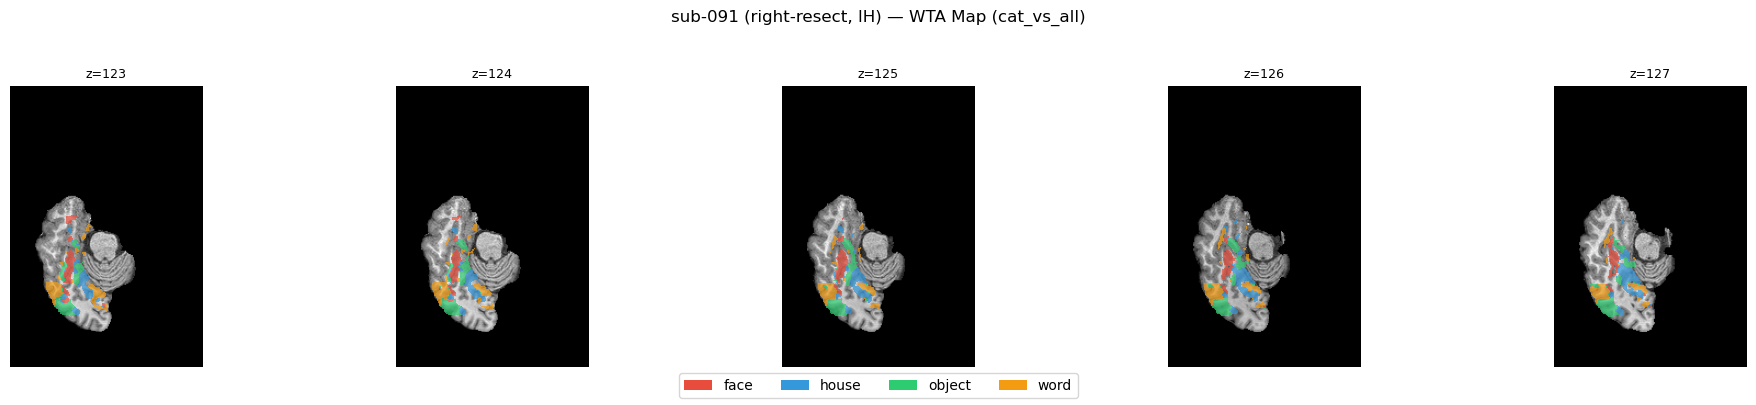

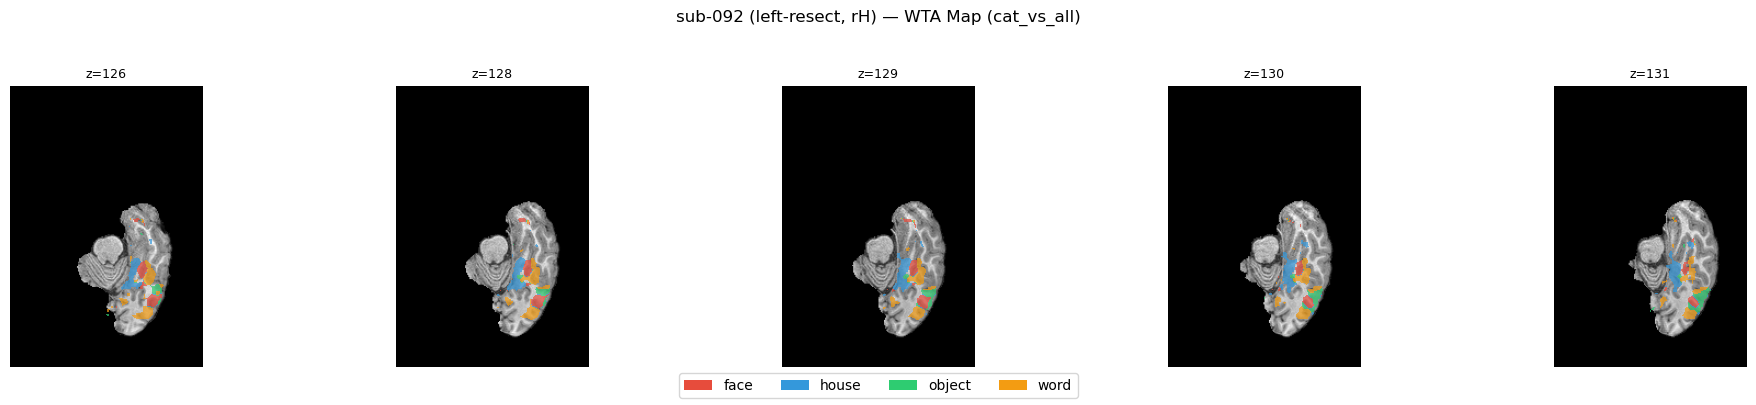

In [5]:
# ── Nilearn ventral view: WTA maps per patient ──────────────────────────────
try:
    from nilearn import plotting
except ImportError:
    print("nilearn not available — skip this cell")
    plotting = None

wta_cmap = ListedColormap(['#000000', '#E74C3C', '#3498DB', '#2ECC71', '#F39C12'])

if plotting:
    patient_sids = sorted([sid for sid, info in subjects.items()
                           if info['patient_status'] == 'OTC'])

    for sid in patient_sids:
        info = subjects[sid]
        actual_first = info['actual_first_ses']
        h = info['hemi']
        first_ses = info['sessions'][0]

        t1_path = os.path.join(processed_dir, sid, f'ses-{actual_first}', 'anat', 'T1w_brain.nii.gz')
        wta_path = os.path.join(wta_nifti_dir, f'{sid}_ses-{first_ses}_{h}h_wta.nii.gz')

        if not os.path.exists(t1_path) or not os.path.exists(wta_path):
            print(f"  SKIP {sid}: missing files")
            continue

        wta_data = nib.load(wta_path).get_fdata()
        t1_brain = nib.load(t1_path).get_fdata()

        z_counts = [(z, np.sum(wta_data[:, :, z] > 0)) for z in range(wta_data.shape[2])]
        z_counts.sort(key=lambda x: x[1], reverse=True)
        best_slices = sorted([z for z, c in z_counts[:5]])

        surgery = info.get('surgery_side', '?')

        fig, axes = plt.subplots(1, len(best_slices), figsize=(4 * len(best_slices), 4))
        if len(best_slices) == 1:
            axes = [axes]

        for ax, z_slice in zip(axes, best_slices):
            ax.imshow(np.rot90(t1_brain[:, :, z_slice]), cmap='gray', aspect='equal')
            wta_masked = np.ma.masked_where(wta_data[:, :, z_slice] == 0, wta_data[:, :, z_slice])
            ax.imshow(np.rot90(wta_masked), cmap=wta_cmap, vmin=0, vmax=4,
                      aspect='equal', alpha=0.7)
            ax.set_title(f'z={z_slice}', fontsize=9)
            ax.axis('off')

        legend_patches = [Patch(facecolor=c, label=cat)
                          for cat, c in zip(CATEGORIES, ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12'])]
        fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=10)
        plt.suptitle(f'{sid} ({surgery}-resect, {h}H) — WTA Map ({ALLEGIANCE_COPE_SET})', fontsize=12)
        plt.tight_layout(rect=[0, 0.05, 1, 0.95])
        plt.savefig(os.path.join(wta_nifti_dir, f'{sid}_wta_slices.png'), dpi=150, bbox_inches='tight')
        plt.show()

## 3. T1 vs T2 WTA Slice Comparison

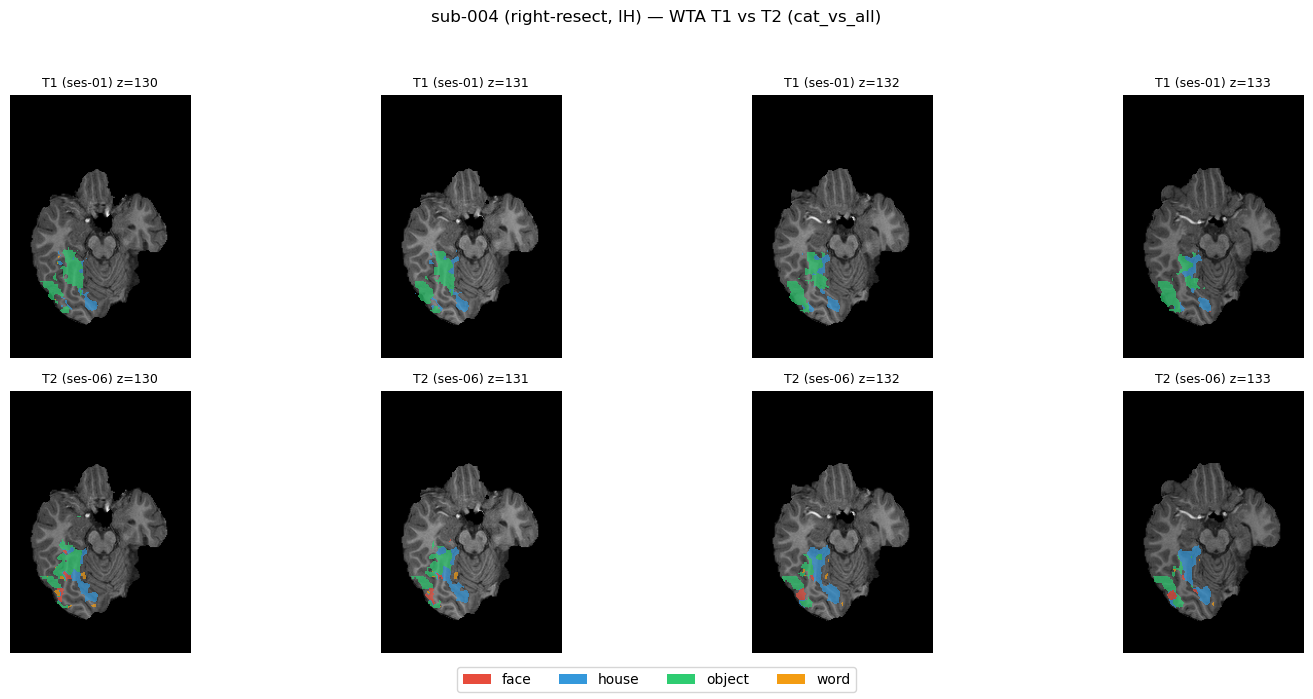

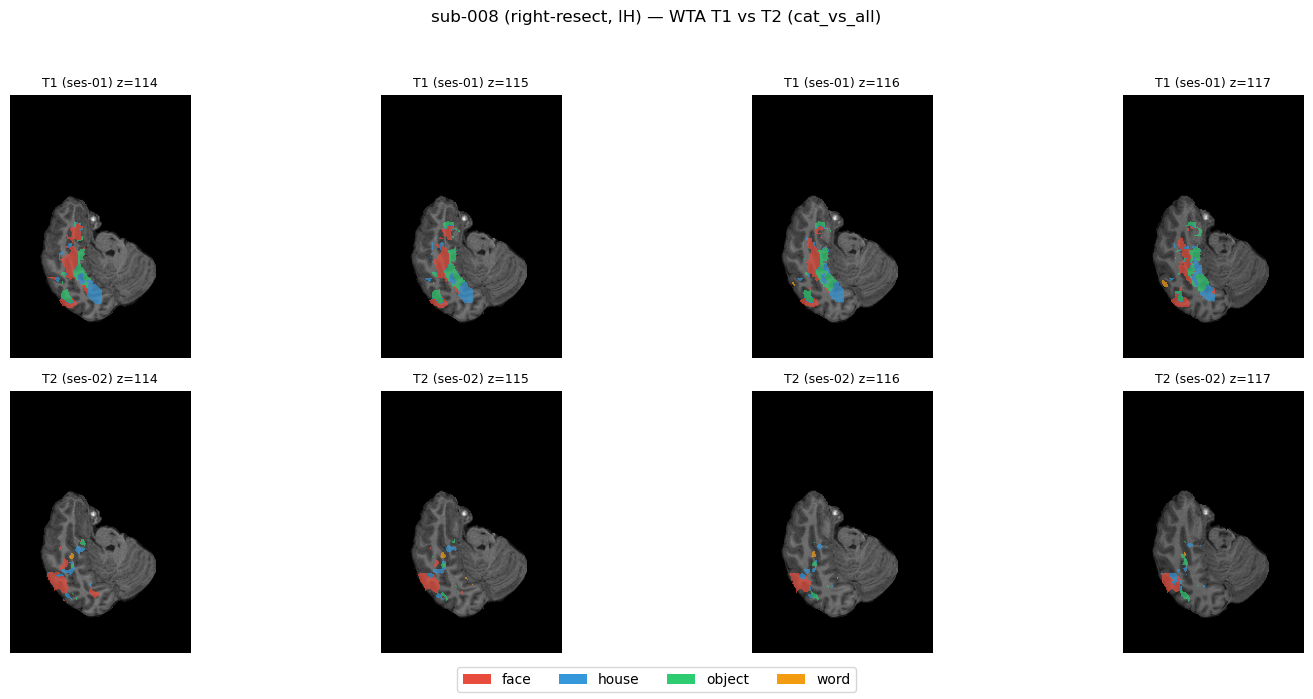

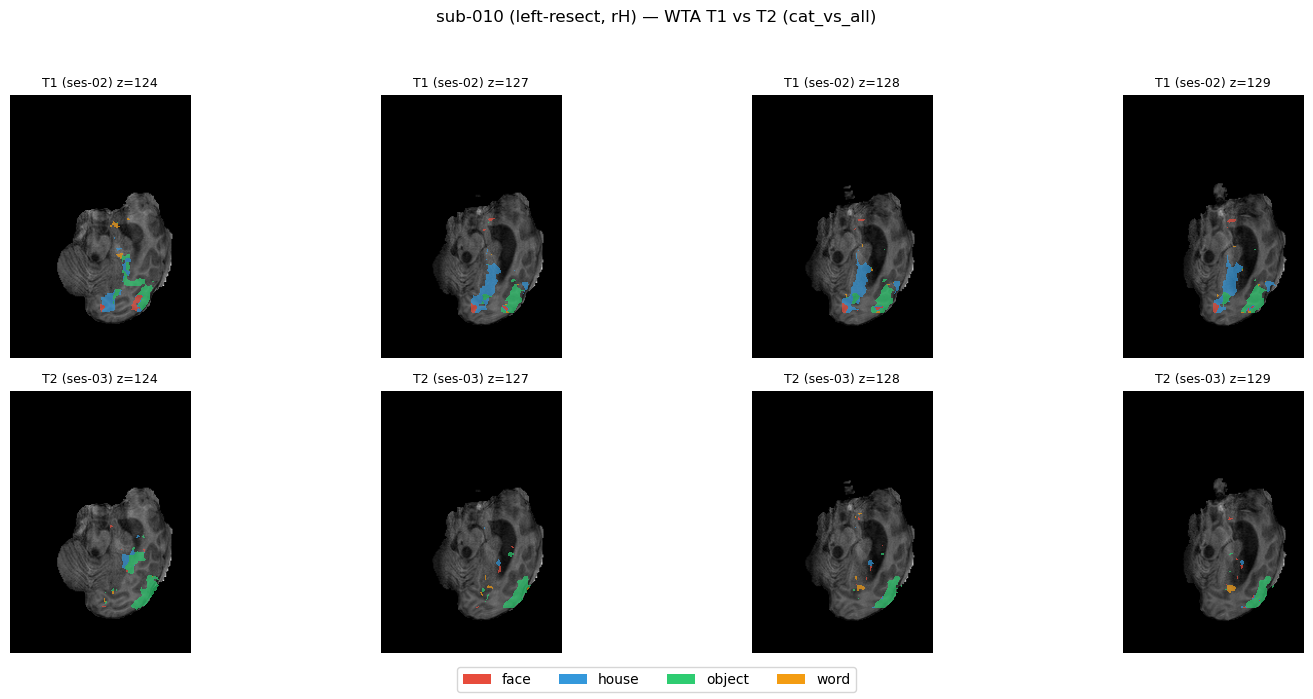

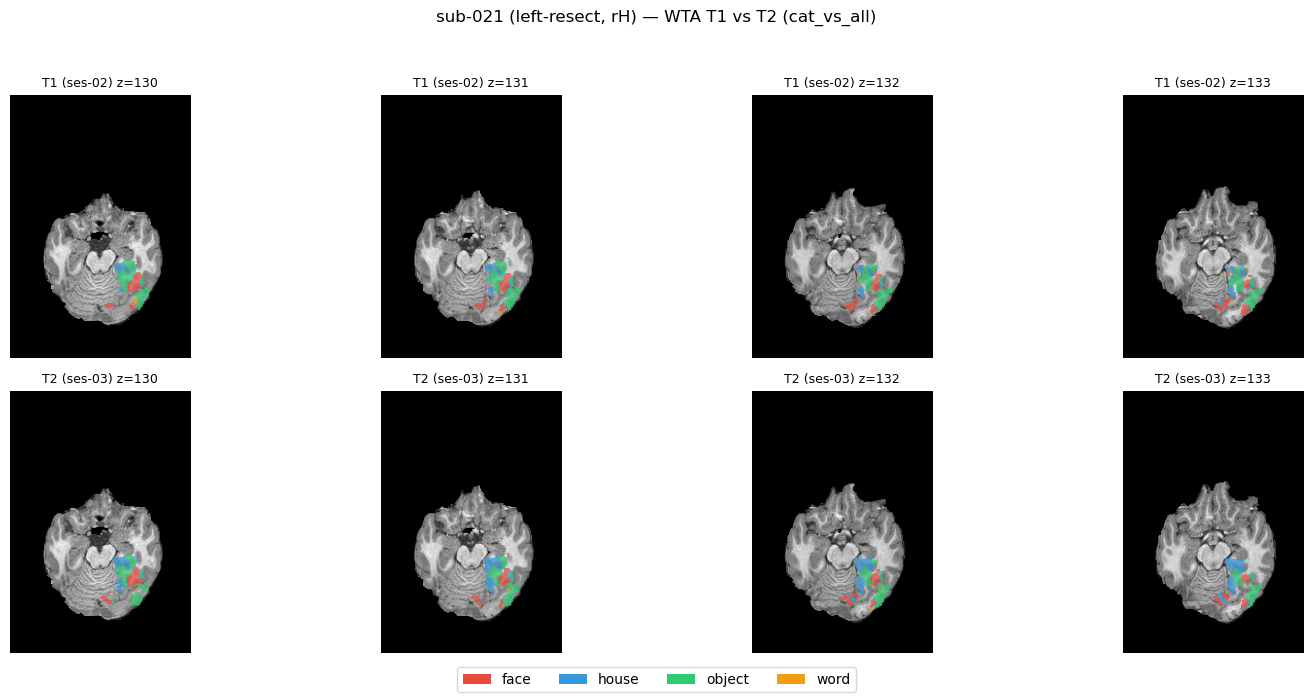

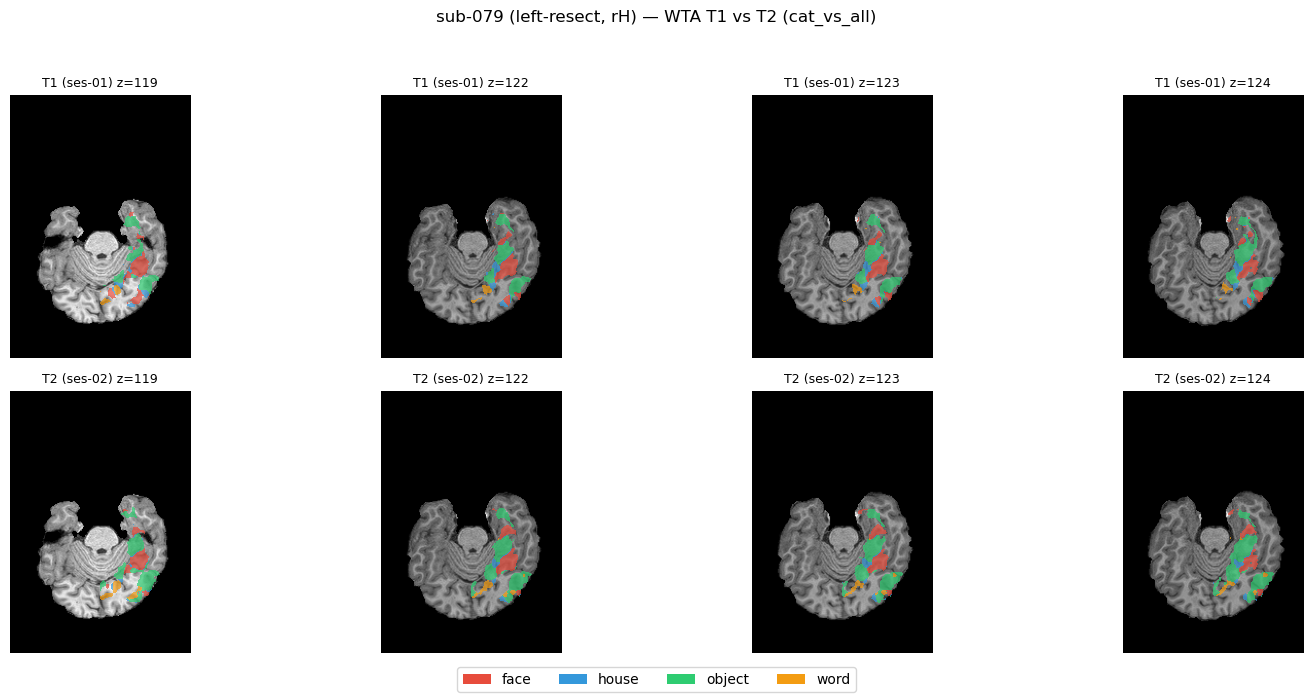

In [6]:
# ── T1 vs T2 WTA slice comparison per patient ────────────────────────────────

wta_cmap = ListedColormap(['#000000', '#E74C3C', '#3498DB', '#2ECC71', '#F39C12'])

for sid in sorted(long_subs.keys()):
    info = long_subs[sid]
    if info['patient_status'] != 'OTC':
        continue

    actual_first = info['actual_first_ses']
    h = info['hemi']
    sessions = info['sessions']
    t1_ses, t2_ses = sessions[0], sessions[-1]
    surgery = info.get('surgery_side', '?')

    t1_path = os.path.join(processed_dir, sid, f'ses-{actual_first}', 'anat', 'T1w_brain.nii.gz')
    wta_t1_path = os.path.join(wta_nifti_dir, f'{sid}_ses-{t1_ses}_{h}h_wta.nii.gz')
    wta_t2_path = os.path.join(wta_nifti_dir, f'{sid}_ses-{t2_ses}_{h}h_wta.nii.gz')

    if not all(os.path.exists(p) for p in [t1_path, wta_t1_path, wta_t2_path]):
        print(f"  SKIP {sid}: missing files")
        continue

    t1_brain = nib.load(t1_path).get_fdata()
    wta_t1_data = nib.load(wta_t1_path).get_fdata()
    wta_t2_data = nib.load(wta_t2_path).get_fdata()

    z_counts = [(z, np.sum(wta_t1_data[:, :, z] > 0)) for z in range(wta_t1_data.shape[2])]
    z_counts.sort(key=lambda x: x[1], reverse=True)
    best_slices = sorted([z for z, c in z_counts[:4]])

    fig, axes = plt.subplots(2, len(best_slices), figsize=(4 * len(best_slices), 7))

    for col, z_slice in enumerate(best_slices):
        for row, (wta_data, label) in enumerate([(wta_t1_data, f'T1 (ses-{t1_ses})'),
                                                   (wta_t2_data, f'T2 (ses-{t2_ses})')]):
            ax = axes[row, col]
            ax.imshow(np.rot90(t1_brain[:, :, z_slice]), cmap='gray', aspect='equal')
            wta_masked = np.ma.masked_where(wta_data[:, :, z_slice] == 0,
                                             wta_data[:, :, z_slice])
            ax.imshow(np.rot90(wta_masked), cmap=wta_cmap, vmin=0, vmax=4,
                      aspect='equal', alpha=0.7)
            ax.set_title(f'{label} z={z_slice}', fontsize=9)
            ax.axis('off')

    legend_patches = [Patch(facecolor=c, label=cat)
                      for cat, c in zip(CATEGORIES, ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12'])]
    fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=10)
    plt.suptitle(f'{sid} ({surgery}-resect, {h}H) — WTA T1 vs T2 ({ALLEGIANCE_COPE_SET})', fontsize=12)
    plt.tight_layout(rect=[0, 0.04, 1, 0.95])
    plt.savefig(os.path.join(wta_nifti_dir, f'{sid}_wta_t1vt2_slices.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 4. Diagnostic: Patient Transition Details

In [7]:
# ── Print detailed patient transition matrices ───────────────────────────────

for (sid, h), res in sorted(transition_results.items()):
    if res['group'] != 'OTC':
        continue

    surgery = res.get('surgery_side', '?')
    tp = res['trans_pct']
    print(f"\n{sid} ({h}H, {surgery}-resection), retention={res['retention']:.3f}")
    print(f"{'':>8} {'→Face':>8} {'→House':>8} {'→Obj':>8} {'→Word':>8}")
    for i, cat in enumerate(CATEGORIES):
        print(f"{cat:>8} {tp[i,0]:>7.1f}% {tp[i,1]:>7.1f}% {tp[i,2]:>7.1f}% {tp[i,3]:>7.1f}%")


sub-004 (lH, right-resection), retention=0.687
            →Face   →House     →Obj    →Word
    face    80.3%     8.2%     5.9%     5.7%
   house     2.0%    73.5%    12.5%    12.1%
  object    11.5%    19.3%    64.2%     5.0%
    word    12.7%     8.7%    33.3%    45.2%

sub-008 (lH, right-resection), retention=0.301
            →Face   →House     →Obj    →Word
    face    42.8%    30.0%    20.2%     7.0%
   house    48.0%    22.3%    27.1%     2.6%
  object    31.8%    48.3%     9.7%    10.2%
    word    34.1%    24.3%    32.4%     9.1%

sub-010 (rH, left-resection), retention=0.482
            →Face   →House     →Obj    →Word
    face    19.5%    20.9%    52.5%     7.0%
   house    19.5%    18.0%    50.6%    11.8%
  object     7.1%    10.7%    77.6%     4.6%
    word     2.7%    27.8%    48.3%    21.2%

sub-021 (rH, left-resection), retention=0.740
            →Face   →House     →Obj    →Word
    face    90.2%     2.9%     6.2%     0.6%
   house     4.4%    90.2%     4.2%     1.3%


## 5. Diagnostic: Control Word→Object Rates

In [8]:
# ── Control word→object transition rate ───────────────────────────────────────

for (sid, h), res in sorted(transition_results.items()):
    if res['group'] == 'control':
        tp = res['trans_pct']
        print(f"{sid} ({h}H): word→obj = {tp[3,2]:.1f}%, word retention = {tp[3,3]:.1f}%")

sub-018 (lH): word→obj = 9.8%, word retention = 70.4%
sub-018 (rH): word→obj = 4.2%, word retention = 23.7%
sub-022 (lH): word→obj = 54.5%, word retention = 25.5%
sub-022 (rH): word→obj = 51.1%, word retention = 11.0%
sub-025 (lH): word→obj = 17.2%, word retention = 62.7%
sub-025 (rH): word→obj = 59.5%, word retention = 22.7%
sub-052 (lH): word→obj = 3.9%, word retention = 84.8%
sub-052 (rH): word→obj = 2.9%, word retention = 84.7%
sub-058 (lH): word→obj = 48.3%, word retention = 49.7%
sub-058 (rH): word→obj = 21.0%, word retention = 75.7%
sub-062 (lH): word→obj = 0.6%, word retention = 86.2%
sub-062 (rH): word→obj = 1.1%, word retention = 93.7%
sub-064 (lH): word→obj = 3.1%, word retention = 94.5%
sub-064 (rH): word→obj = 18.8%, word retention = 74.8%
sub-068 (lH): word→obj = 27.7%, word retention = 43.4%
sub-068 (rH): word→obj = 4.7%, word retention = 76.3%


Group control maps...


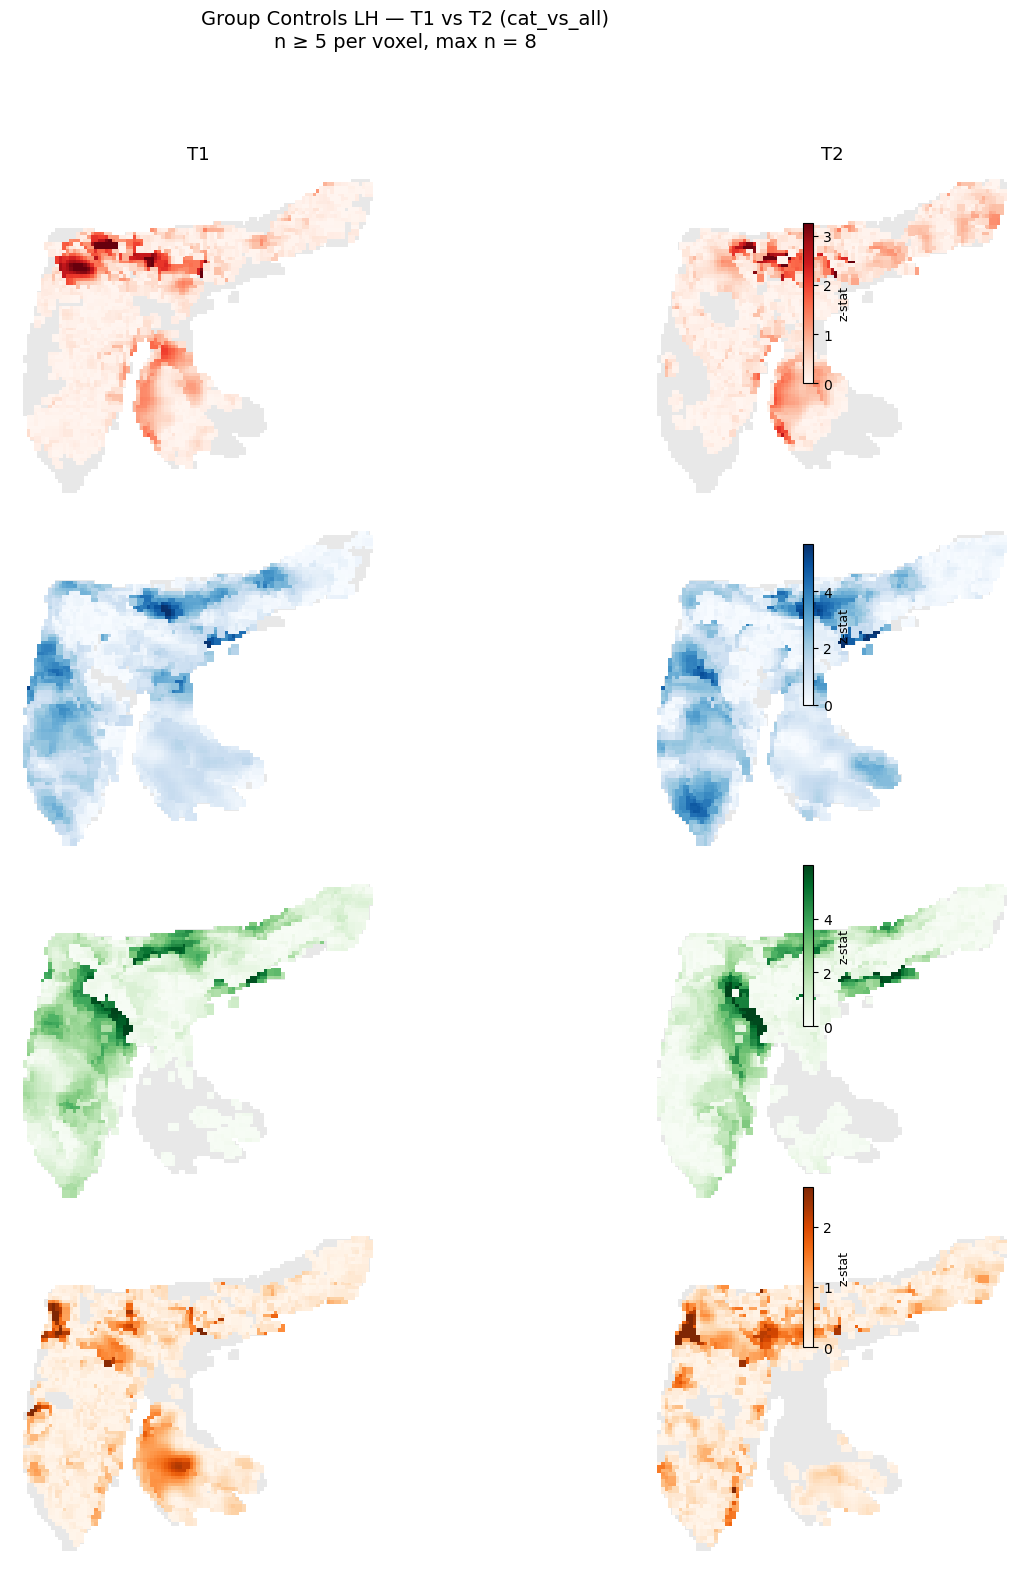

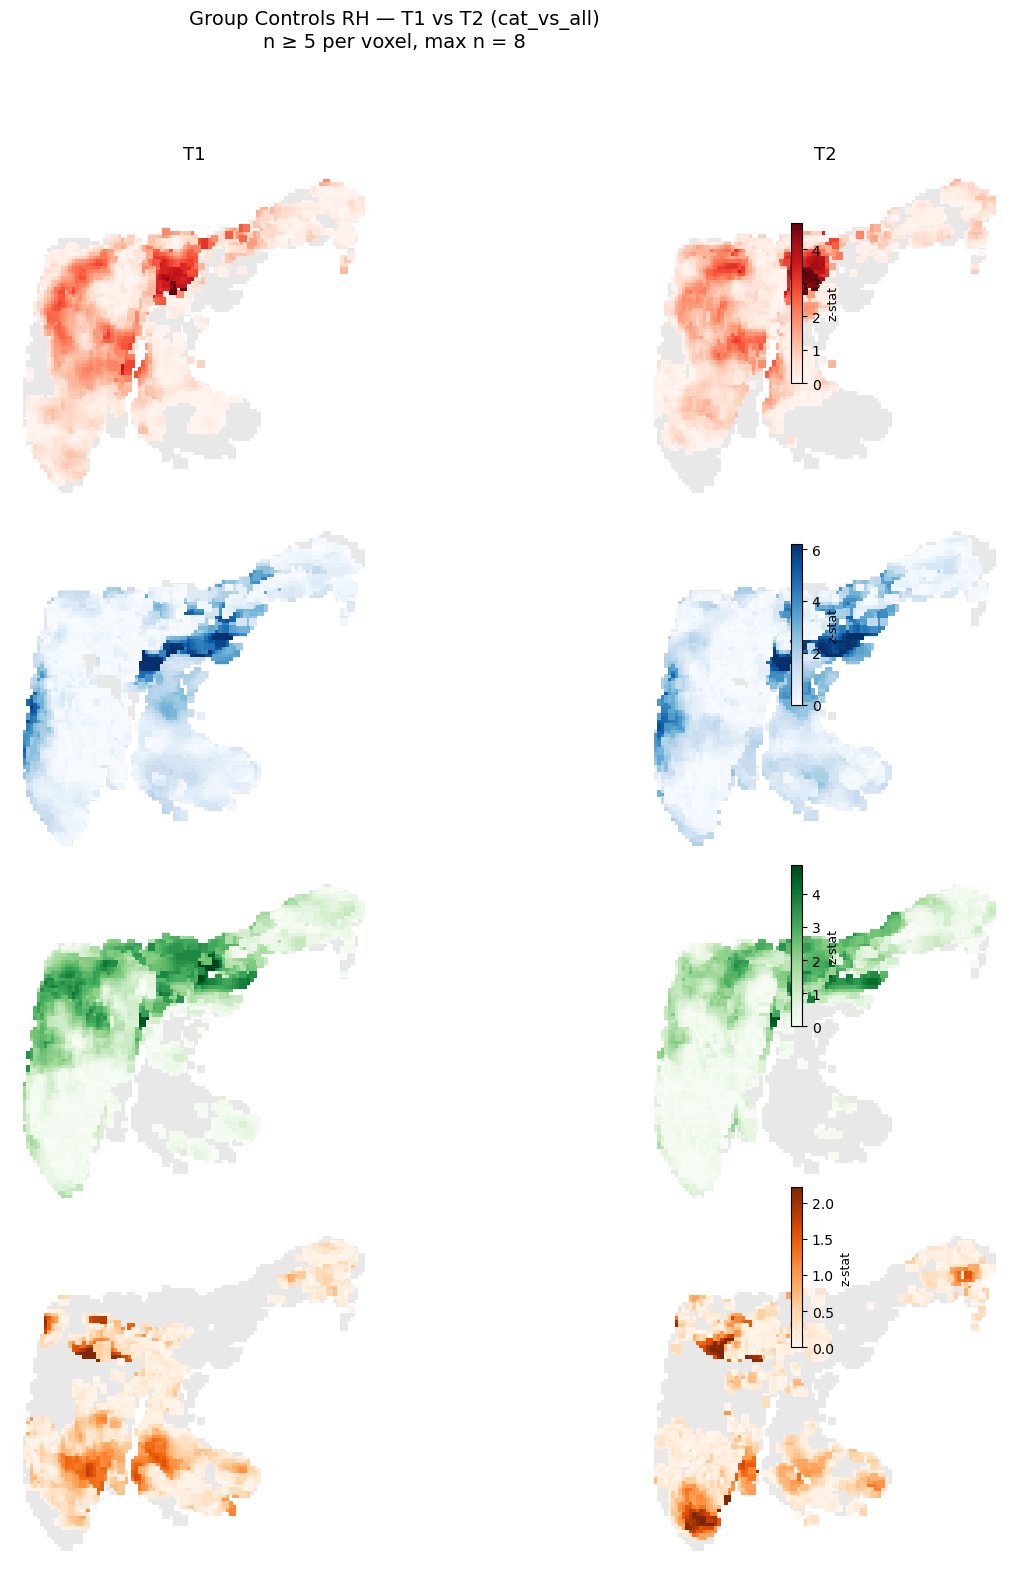

In [ ]:
# ── Category Selectivity Heatmaps ────────────────────────────────────────────
# Continuous z-stat (cat > all others) per voxel. No thresholding — colormap
# does the work (faint=weak, dark=strong). Shared scale across sessions.

from matplotlib.colors import Normalize
import matplotlib.cm as cm

CAT_CMAPS = {'face': 'Reds', 'house': 'Blues', 'object': 'Greens', 'word': 'Oranges'}
POINT_SIZE = 30


# ── Core plotting function ───────────────────────────────────────────────────

def plot_selectivity_scatter(vals, coords, ax, cmap, vmax, point_size=POINT_SIZE):
    """Plot one category's selectivity. Gray background + colored positive voxels."""
    ax.scatter(coords[:, 1], coords[:, 2], c='#e8e8e8', s=point_size,
               marker='s', linewidths=0, rasterized=True, zorder=1)
    show = vals > 0
    if show.sum() > 0:
        norm = Normalize(vmin=0, vmax=vmax)
        ax.scatter(coords[show, 1], coords[show, 2], c=vals[show], cmap=cmap,
                   norm=norm, s=point_size, marker='s', linewidths=0,
                   rasterized=True, zorder=2)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')


def add_colorbar(fig, axes_row, cmap, vmax):
    sm = cm.ScalarMappable(cmap=cmap, norm=Normalize(vmin=0, vmax=vmax))
    sm.set_array([])
    # Use the last axis to anchor, place outside figure
    cbar = fig.colorbar(sm, ax=axes_row if isinstance(axes_row, list) else [axes_row],
                        shrink=0.6, pad=0.15, aspect=15, location='right')
    cbar.set_label('z-stat', fontsize=9)


# ── Shared vmax computation ──────────────────────────────────────────────────

def get_joint_vmax(sid, sessions, actual_first, h, mask_3d, pct=98):
    """Compute shared vmax per category across sessions for one subject."""
    cat_maxes = {cat: [] for cat in CATEGORIES}
    for ses in sessions:
        betas = load_category_betas(sid, ses, actual_first, mask_3d, cope_map)
        if betas is None:
            continue
        for cat in CATEGORIES:
            above = betas[cat][betas[cat] > 0]
            if len(above) > 0:
                cat_maxes[cat].append(np.percentile(above, pct))
    return {cat: max(cat_maxes[cat]) if cat_maxes[cat] else 5.0 for cat in CATEGORIES}


# ── Individual subject: 4-category × 2-session grid ─────────────────────────

def plot_selectivity_grid(sid, info):
    actual_first = info['actual_first_ses']
    t1_ses, t2_ses = info['sessions'][0], info['sessions'][-1]
    hemis = [info['hemi']] if info['patient_status'] == 'OTC' else ['l', 'r']

    for h in hemis:
        mask_3d, _ = get_votc_mask(sid, actual_first, h)
        if mask_3d is None:
            continue

        coords = np.array(np.where(mask_3d)).T
        vmax = get_joint_vmax(sid, [t1_ses, t2_ses], actual_first, h, mask_3d)

        fig, axes = plt.subplots(4, 2, figsize=(12, 16))

        for row, cat in enumerate(CATEGORIES):
            for col, ses in enumerate([t1_ses, t2_ses]):
                betas = load_category_betas(sid, ses, actual_first, mask_3d, cope_map)
                vals = betas[cat] if betas is not None else np.zeros(coords.shape[0])
                plot_selectivity_scatter(vals, coords, axes[row, col],
                                         CAT_CMAPS[cat], vmax[cat])
            axes[row, 0].set_ylabel(cat.capitalize(), fontsize=14,
                                     rotation=0, labelpad=50, va='center')
            add_colorbar(fig, axes[row, :].tolist(), CAT_CMAPS[cat], vmax[cat])

        axes[0, 0].set_title(f'T1 (ses-{t1_ses})', fontsize=13)
        axes[0, 1].set_title(f'T2 (ses-{t2_ses})', fontsize=13)

        hemi_label = 'LH' if h == 'l' else 'RH'
        group = info['patient_status']
        surgery = info.get('surgery_side', 'na')
        title = (f'{sid} ({surgery}-resect, intact {hemi_label})'
                 if group == 'OTC' else f'{sid} ({group}, {hemi_label})')

        plt.suptitle(f'{title} — Category Selectivity ({ALLEGIANCE_COPE_SET})', fontsize=14)
        plt.tight_layout(rect=[0, 0, 0.95, 0.95])
        plt.savefig(os.path.join(processed_dir, 'group_results',
                    f'{sid}_{h}h_selectivity_{ALLEGIANCE_COPE_SET}.png'),
                    dpi=200, bbox_inches='tight')
        plt.show()


# ── Group average: accumulate across controls ────────────────────────────────

def build_group_selectivity(long_subs, hemi, session_idx=0):
    sum_vols, count_vol, ref_shape, ref_affine = None, None, None, None

    for sid, info in long_subs.items():
        if info['patient_status'] != 'control':
            continue

        actual_first = info['actual_first_ses']
        ses = info['sessions'][session_idx]
        mask_3d, affine = get_votc_mask(sid, actual_first, hemi)
        if mask_3d is None:
            continue
        betas = load_category_betas(sid, ses, actual_first, mask_3d, cope_map)
        if betas is None:
            continue

        if sum_vols is None:
            ref_shape, ref_affine = mask_3d.shape, affine
            sum_vols = {cat: np.zeros(ref_shape) for cat in CATEGORIES}
            count_vol = np.zeros(ref_shape)

        if mask_3d.shape != ref_shape:
            print(f"  SKIP {sid} {hemi}H: shape mismatch")
            continue

        where = np.where(mask_3d)
        count_vol[where] += 1
        for cat in CATEGORIES:
            vol = np.zeros(ref_shape)
            vol[mask_3d] = betas[cat]
            sum_vols[cat][where] += vol[where]

    if sum_vols is None:
        return None

    valid = count_vol > 0
    avg_vols = {}
    for cat in CATEGORIES:
        avg = np.zeros(ref_shape)
        avg[valid] = sum_vols[cat][valid] / count_vol[valid]
        avg_vols[cat] = avg

    return avg_vols, count_vol, ref_shape, ref_affine


# ── Group T1 vs T2 side-by-side ──────────────────────────────────────────────

def plot_group_t1vt2(hemi, long_subs, min_subjects=3):
    result_t1 = build_group_selectivity(long_subs, hemi, session_idx=0)
    result_t2 = build_group_selectivity(long_subs, hemi, session_idx=-1)

    if result_t1 is None or result_t2 is None:
        print(f"  Insufficient data for {hemi}H group map")
        return

    avg_t1, count_t1, _, _ = result_t1
    avg_t2, count_t2, _, _ = result_t2

    joint_mask = (count_t1 >= min_subjects) & (count_t2 >= min_subjects)
    coords = np.array(np.where(joint_mask)).T
    if coords.shape[0] == 0:
        print(f"  No voxels with >= {min_subjects} subjects")
        return

    # Shared vmax across sessions
    vmax = {}
    for cat in CATEGORIES:
        pooled = np.concatenate([avg_t1[cat][joint_mask][avg_t1[cat][joint_mask] > 0],
                                  avg_t2[cat][joint_mask][avg_t2[cat][joint_mask] > 0]])
        vmax[cat] = np.percentile(pooled, 98) if len(pooled) > 0 else 5.0

    fig, axes = plt.subplots(4, 2, figsize=(14, 16))

    for row, cat in enumerate(CATEGORIES):
        for col, (avg, label) in enumerate([(avg_t1, 'T1'), (avg_t2, 'T2')]):
            vals = avg[cat][joint_mask]
            plot_selectivity_scatter(vals, coords, axes[row, col],
                                     CAT_CMAPS[cat], vmax[cat])
            if row == 0:
                axes[row, col].set_title(label, fontsize=13)

        axes[row, 0].set_ylabel(cat.capitalize(), fontsize=14,
                                 rotation=0, labelpad=50, va='center')
        add_colorbar(fig, axes[row, :].tolist(), CAT_CMAPS[cat], vmax[cat])

    hemi_label = 'LH' if hemi == 'l' else 'RH'
    n_max = int(min(count_t1[joint_mask].max(), count_t2[joint_mask].max()))
    plt.suptitle(f'Group Controls {hemi_label} — T1 vs T2 ({ALLEGIANCE_COPE_SET})\n'
                 f'n ≥ {min_subjects} per voxel, max n = {n_max}', fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.95, 0.94])
    plt.savefig(os.path.join(processed_dir, 'group_results',
                f'group_ctrl_{hemi}h_selectivity_t1vt2_{ALLEGIANCE_COPE_SET}.png'),
                dpi=200, bbox_inches='tight')
    plt.show()


# ── Run ──────────────────────────────────────────────────────────────────────

'''
# Individual patients
print("Patients...")
for sid in sorted(long_subs.keys()):
    info = long_subs[sid]
    if info['patient_status'] == 'OTC':
        plot_selectivity_grid(sid, info)
        
'''

'''
# Individual controls
print("Controls...")
for sid in sorted(long_subs.keys()):
    info = long_subs[sid]
    if info['patient_status'] == 'control':
        plot_selectivity_grid(sid, info)
'''

# Group averages
print("Group control maps...")
for hemi in ['l', 'r']:
    plot_group_t1vt2(hemi, long_subs)

Group control reliability maps...


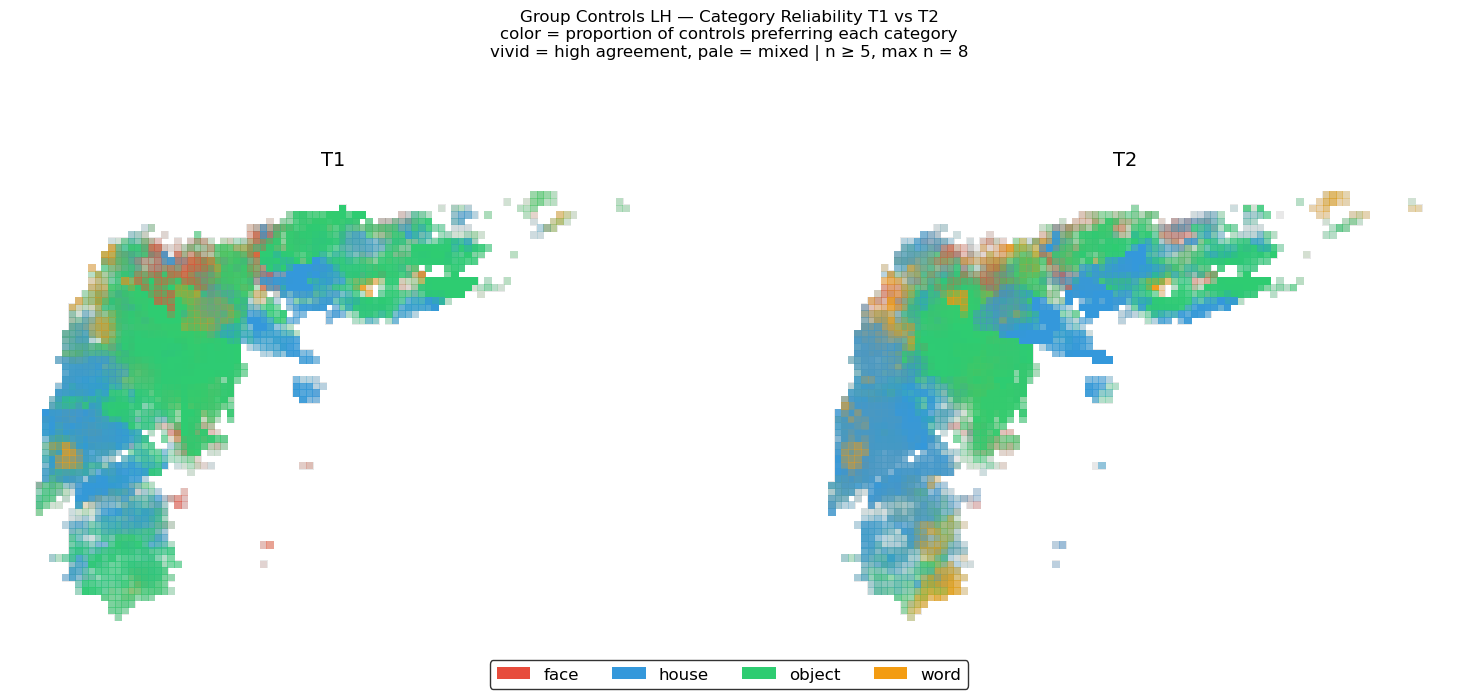

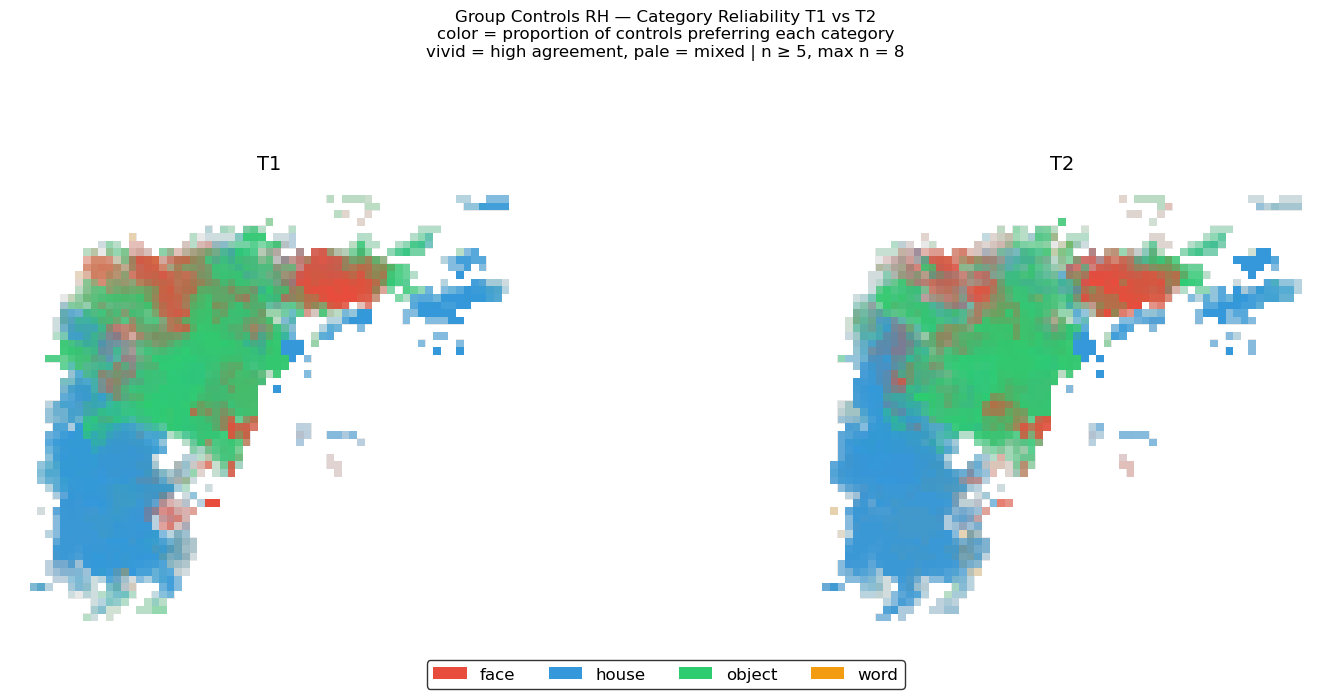

In [27]:
# ── Reliability-Based Blended Maps: Group Controls ───────────────────────────
# Each voxel's color = proportion of controls agreeing on each category.
# Vivid = high agreement, pale = low agreement / mixed.

CAT_RGB = {
    0: np.array([0.906, 0.298, 0.235]),  # face - red
    1: np.array([0.204, 0.596, 0.859]),  # house - blue
    2: np.array([0.180, 0.800, 0.443]),  # object - green
    3: np.array([0.953, 0.612, 0.071]),  # word - orange
}

POINT_SIZE = 30


def build_group_votes(long_subs, hemi, session_idx=0, z_thresh=1.96):
    """
    For each voxel, count how many controls prefer each category.
    Returns: vote_vols {cat: 3d count array}, count_vol, ref_shape, ref_affine
    """
    vote_vols, count_vol, ref_shape, ref_affine = None, None, None, None

    for sid, info in long_subs.items():
        if info['patient_status'] != 'control':
            continue

        actual_first = info['actual_first_ses']
        ses = info['sessions'][session_idx]
        mask_3d, affine = get_votc_mask(sid, actual_first, hemi)
        if mask_3d is None:
            continue
        betas = load_category_betas(sid, ses, actual_first, mask_3d, cope_map)
        if betas is None:
            continue

        if vote_vols is None:
            ref_shape, ref_affine = mask_3d.shape, affine
            vote_vols = {cat: np.zeros(ref_shape) for cat in CATEGORIES}
            count_vol = np.zeros(ref_shape)

        if mask_3d.shape != ref_shape:
            print(f"  SKIP {sid} {hemi}H: shape mismatch")
            continue

        # WTA per voxel for this subject
        beta_matrix = np.column_stack([betas[cat] for cat in CATEGORIES])
        max_vals = np.max(beta_matrix, axis=1)
        winners = np.argmax(beta_matrix, axis=1)

        # Only count voxels where at least one category passes threshold
        supra = max_vals > z_thresh

        where = np.where(mask_3d)
        for idx in range(len(winners)):
            if not supra[idx]:
                continue
            x, y, z = where[0][idx], where[1][idx], where[2][idx]
            count_vol[x, y, z] += 1
            vote_vols[CATEGORIES[winners[idx]]][x, y, z] += 1

    if vote_vols is None:
        return None

    return vote_vols, count_vol, ref_shape, ref_affine


def plot_reliability_map(coords, vote_vals, n_subjects, ax, point_size=POINT_SIZE,
                         agreement_floor=0.35):
    """
    Blended map where color = proportion voting for each category,
    alpha = agreement strength. Floor just above chance (0.25).
    """
    # Gray background
    ax.scatter(coords[:, 1], coords[:, 2], c='#e8e8e8', s=point_size,
               marker='s', linewidths=0, rasterized=True, zorder=1)

    show = n_subjects > 0
    if show.sum() == 0:
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.axis('off')
        return

    # Proportions per category
    props = np.column_stack([vote_vals[cat][show] for cat in CATEGORIES])
    props = props / n_subjects[show, None]

    # Blend RGB by proportion
    cat_colors = np.array([CAT_RGB[i] for i in range(4)])
    blended_rgb = props @ cat_colors

    # Agreement: max proportion across categories
    max_prop = np.max(props, axis=1)

    # Floor: just above chance
    clear = max_prop >= agreement_floor
    if clear.sum() == 0:
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.axis('off')
        return

    # Steeper alpha ramp: emphasize high agreement, keep low agreement visible but faint
    # Square the normalized proportion to make vivid regions pop
    norm_prop = (max_prop[clear] - agreement_floor) / (1.0 - agreement_floor)
    alpha = 0.15 + 0.85 * (norm_prop ** 2)  # squared = steeper contrast

    # Boost saturation: push blended color toward the winner's pure color
    winner_idx = np.argmax(props[clear], axis=1)
    winner_prop = max_prop[clear]
    boosted_rgb = np.zeros_like(blended_rgb[clear])
    for i in range(len(boosted_rgb)):
        pure = cat_colors[winner_idx[i]]
        blend = blended_rgb[clear][i]
        # Interpolate: higher agreement → more pure color
        boost = np.clip((winner_prop[i] - 0.25) / 0.75, 0, 1) ** 0.5
        boosted_rgb[i] = blend * (1 - boost) + pure * boost

    colors = np.zeros((clear.sum(), 4))
    colors[:, 0:3] = boosted_rgb
    colors[:, 3] = alpha

    show_coords = coords[show]
    ax.scatter(show_coords[clear, 1], show_coords[clear, 2], c=colors, s=point_size,
               marker='s', linewidths=0, rasterized=True, zorder=2)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')


def plot_group_reliability(hemi, long_subs, min_subjects=5):
    """Group reliability map: T1 vs T2 side by side."""
    result_t1 = build_group_votes(long_subs, hemi, session_idx=0)
    result_t2 = build_group_votes(long_subs, hemi, session_idx=-1)

    if result_t1 is None or result_t2 is None:
        print(f"  Insufficient data for {hemi}H")
        return

    votes_t1, count_t1, _, _ = result_t1
    votes_t2, count_t2, _, _ = result_t2

    joint_mask = (count_t1 >= min_subjects) & (count_t2 >= min_subjects)
    coords = np.array(np.where(joint_mask)).T
    if coords.shape[0] == 0:
        print(f"  No voxels with >= {min_subjects} subjects")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    vote_vals_t1 = {cat: votes_t1[cat][joint_mask] for cat in CATEGORIES}
    n_t1 = count_t1[joint_mask]
    plot_reliability_map(coords, vote_vals_t1, n_t1, axes[0])
    axes[0].set_title('T1', fontsize=14)

    vote_vals_t2 = {cat: votes_t2[cat][joint_mask] for cat in CATEGORIES}
    n_t2 = count_t2[joint_mask]
    plot_reliability_map(coords, vote_vals_t2, n_t2, axes[1])
    axes[1].set_title('T2', fontsize=14)

    # Legend
    legend_patches = [Patch(facecolor=CAT_RGB[i], label=CATEGORIES[i]) for i in range(4)]
    fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=12,
               frameon=True, edgecolor='black')

    hemi_label = 'LH' if hemi == 'l' else 'RH'
    n_max = int(min(count_t1[joint_mask].max(), count_t2[joint_mask].max()))
    plt.suptitle(f'Group Controls {hemi_label} — Category Reliability T1 vs T2\n'
                 f'color = proportion of controls preferring each category\n'
                 f'vivid = high agreement, pale = mixed | '
                 f'n ≥ {min_subjects}, max n = {n_max}', fontsize=12)
    plt.tight_layout(rect=[0, 0.06, 1, 0.86])
    plt.savefig(os.path.join(processed_dir, 'group_results',
                f'group_ctrl_{hemi}h_reliability_{ALLEGIANCE_COPE_SET}.png'),
                dpi=200, bbox_inches='tight')
    plt.show()


# ── Run ──────────────────────────────────────────────────────────────────────

print("Group control reliability maps...")
for hemi in ['l', 'r']:
    plot_group_reliability(hemi, long_subs)

Group control reliability grids...


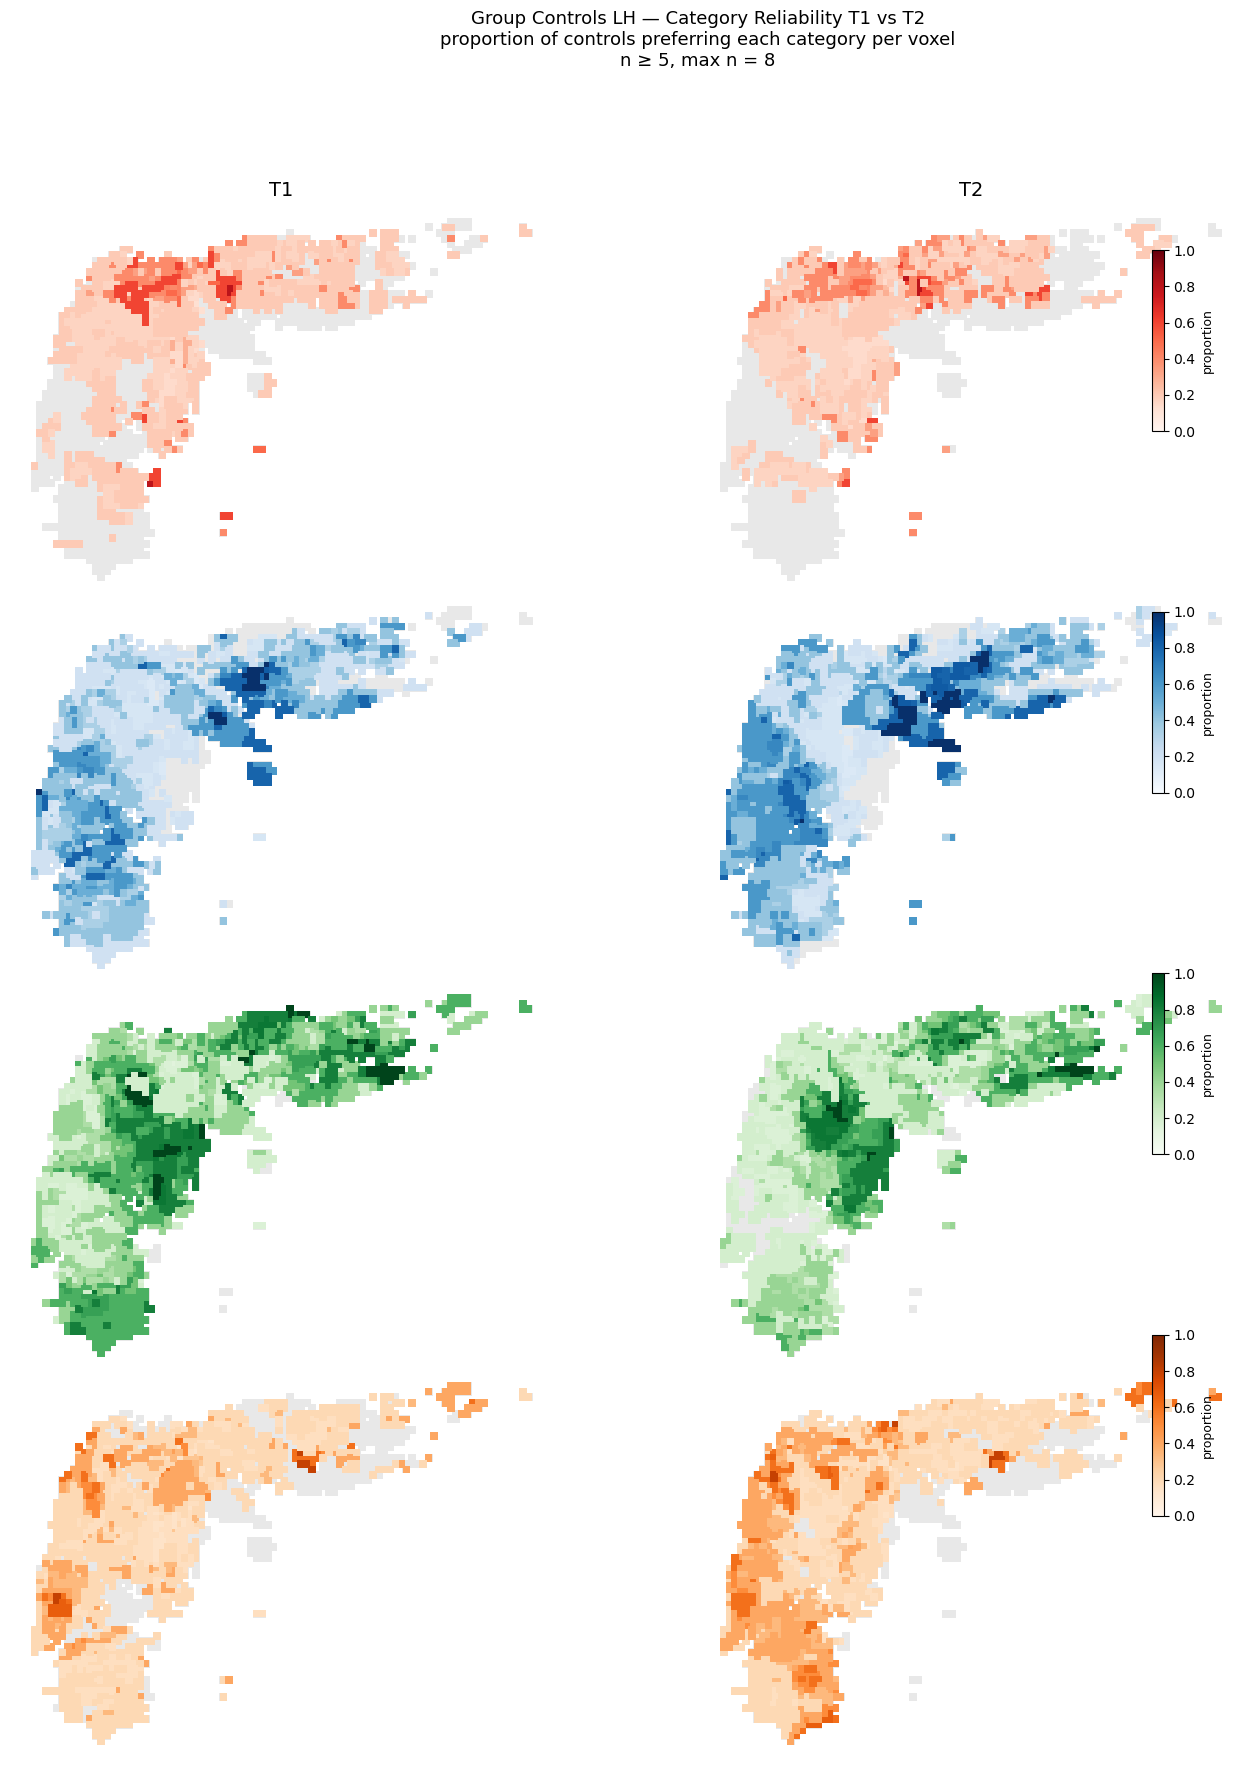

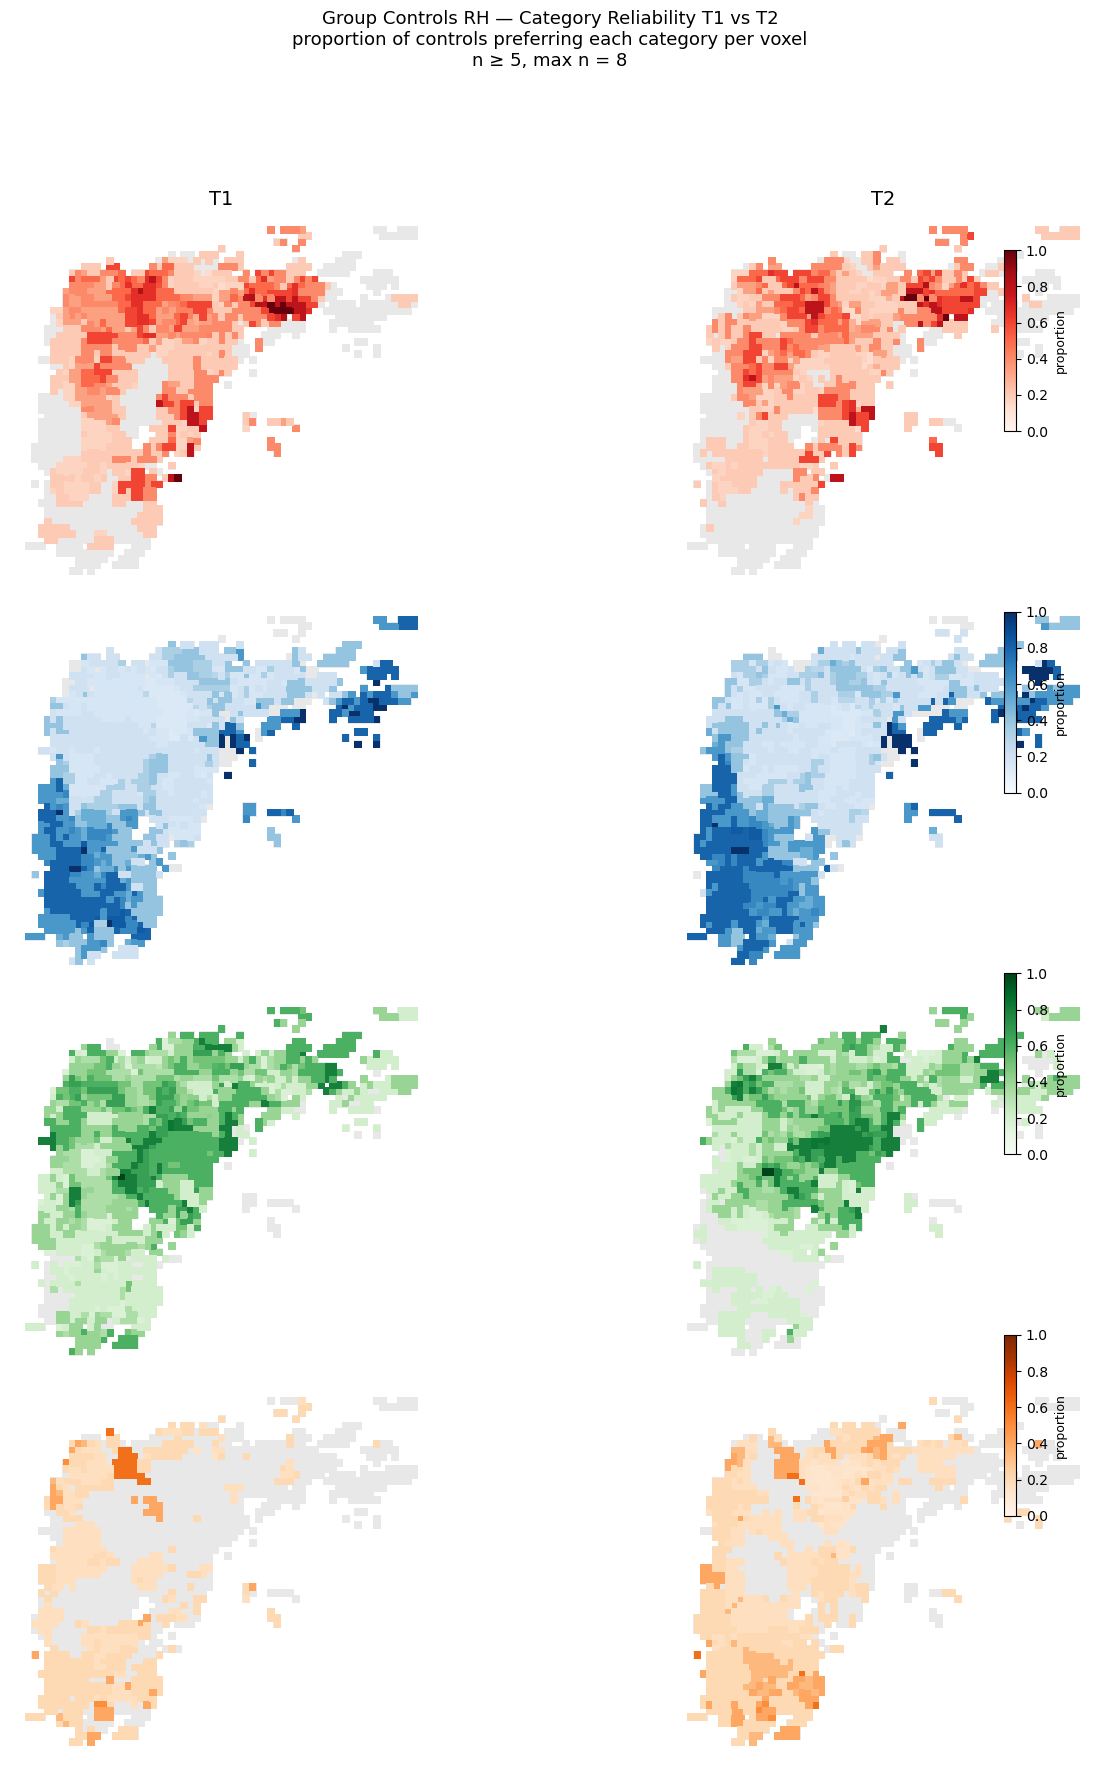

In [28]:
# ── Reliability Heatmaps: Separate panel per category ────────────────────────
# Like the z-stat heatmaps but showing reliability (% controls agreeing).

CAT_CMAPS = {'face': 'Reds', 'house': 'Blues', 'object': 'Greens', 'word': 'Oranges'}
POINT_SIZE = 30


def plot_group_reliability_grid(hemi, long_subs, min_subjects=5, z_thresh=1.96):
    """4-row reliability heatmap: T1 vs T2, one row per category."""
    result_t1 = build_group_votes(long_subs, hemi, session_idx=0, z_thresh=z_thresh)
    result_t2 = build_group_votes(long_subs, hemi, session_idx=-1, z_thresh=z_thresh)

    if result_t1 is None or result_t2 is None:
        print(f"  Insufficient data for {hemi}H")
        return

    votes_t1, count_t1, _, _ = result_t1
    votes_t2, count_t2, _, _ = result_t2

    joint_mask = (count_t1 >= min_subjects) & (count_t2 >= min_subjects)
    coords = np.array(np.where(joint_mask)).T
    if coords.shape[0] == 0:
        print(f"  No voxels with >= {min_subjects} subjects")
        return

    fig, axes = plt.subplots(4, 2, figsize=(16, 18))

    for row, cat in enumerate(CATEGORIES):
        cmap = CAT_CMAPS[cat]

        for col, (votes, count, label) in enumerate([
            (votes_t1, count_t1, 'T1'), (votes_t2, count_t2, 'T2')
        ]):
            ax = axes[row, col]

            # Proportion of controls preferring this category at this voxel
            n = count[joint_mask]
            prop = np.zeros_like(n, dtype=float)
            valid = n > 0
            prop[valid] = votes[cat][joint_mask][valid] / n[valid]

            # Gray background
            ax.scatter(coords[:, 1], coords[:, 2], c='#e8e8e8', s=POINT_SIZE,
                       marker='s', linewidths=0, rasterized=True, zorder=1)

            show = prop > 0
            if show.sum() > 0:
                norm = Normalize(vmin=0, vmax=1)
                ax.scatter(coords[show, 1], coords[show, 2], c=prop[show],
                           cmap=cmap, norm=norm, s=POINT_SIZE, marker='s',
                           linewidths=0, rasterized=True, zorder=2)

            ax.set_aspect('equal')
            ax.invert_yaxis()
            ax.axis('off')

            if row == 0:
                ax.set_title(label, fontsize=14)

        axes[row, 0].set_ylabel(cat.capitalize(), fontsize=14,
                                 rotation=0, labelpad=50, va='center')

        # Shared colorbar
        sm = cm.ScalarMappable(cmap=cmap, norm=Normalize(vmin=0, vmax=1))
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=axes[row, :].tolist(), shrink=0.6,
                             pad=0.15, aspect=15)
        cbar.set_label('proportion', fontsize=9)

    hemi_label = 'LH' if hemi == 'l' else 'RH'
    n_max = int(min(count_t1[joint_mask].max(), count_t2[joint_mask].max()))
    plt.suptitle(f'Group Controls {hemi_label} — Category Reliability T1 vs T2\n'
                 f'proportion of controls preferring each category per voxel\n'
                 f'n ≥ {min_subjects}, max n = {n_max}', fontsize=13)
    plt.tight_layout(rect=[0, 0, 0.85, 0.93])
    plt.savefig(os.path.join(processed_dir, 'group_results',
                f'group_ctrl_{hemi}h_reliability_grid_{ALLEGIANCE_COPE_SET}.png'),
                dpi=200, bbox_inches='tight')
    plt.show()


# ── Run ──────────────────────────────────────────────────────────────────────

print("Group control reliability grids...")
for hemi in ['l', 'r']:
    plot_group_reliability_grid(hemi, long_subs)

Pairwise reliability blends...


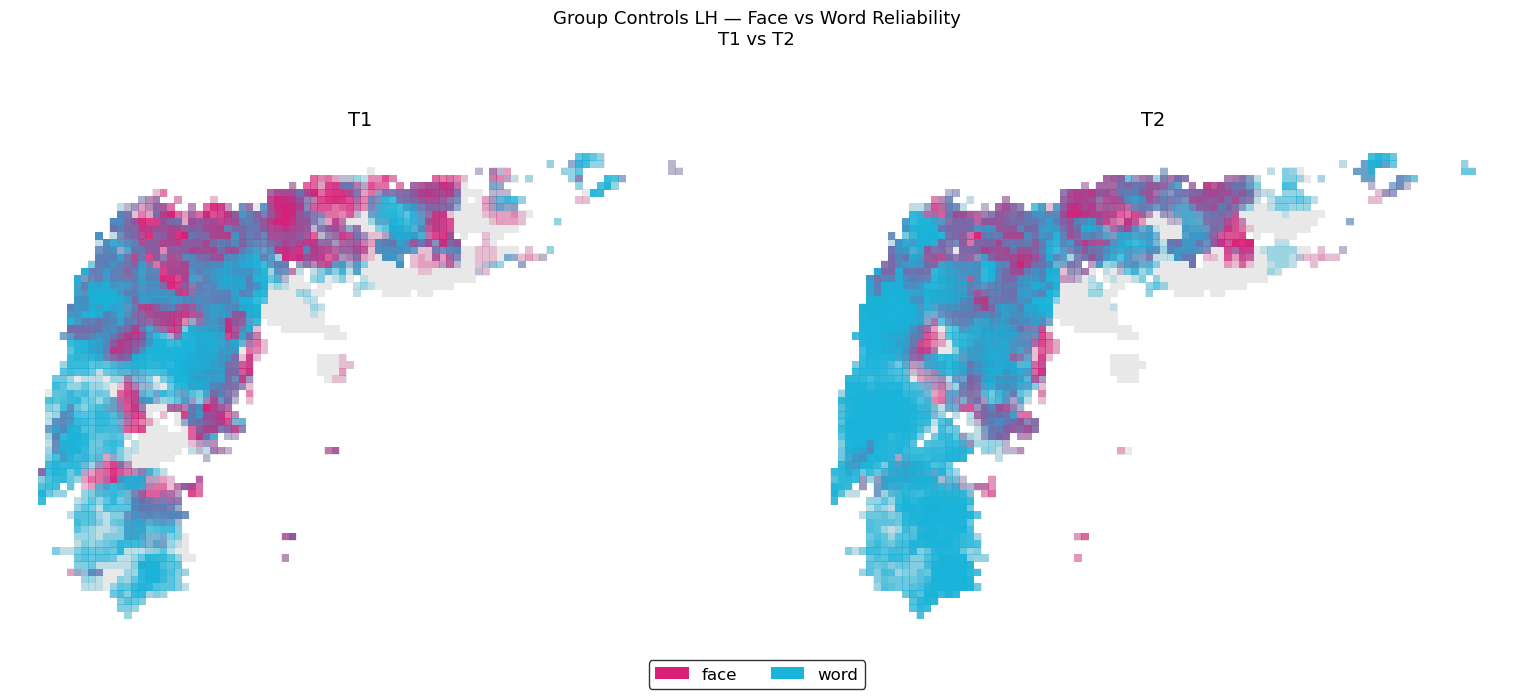

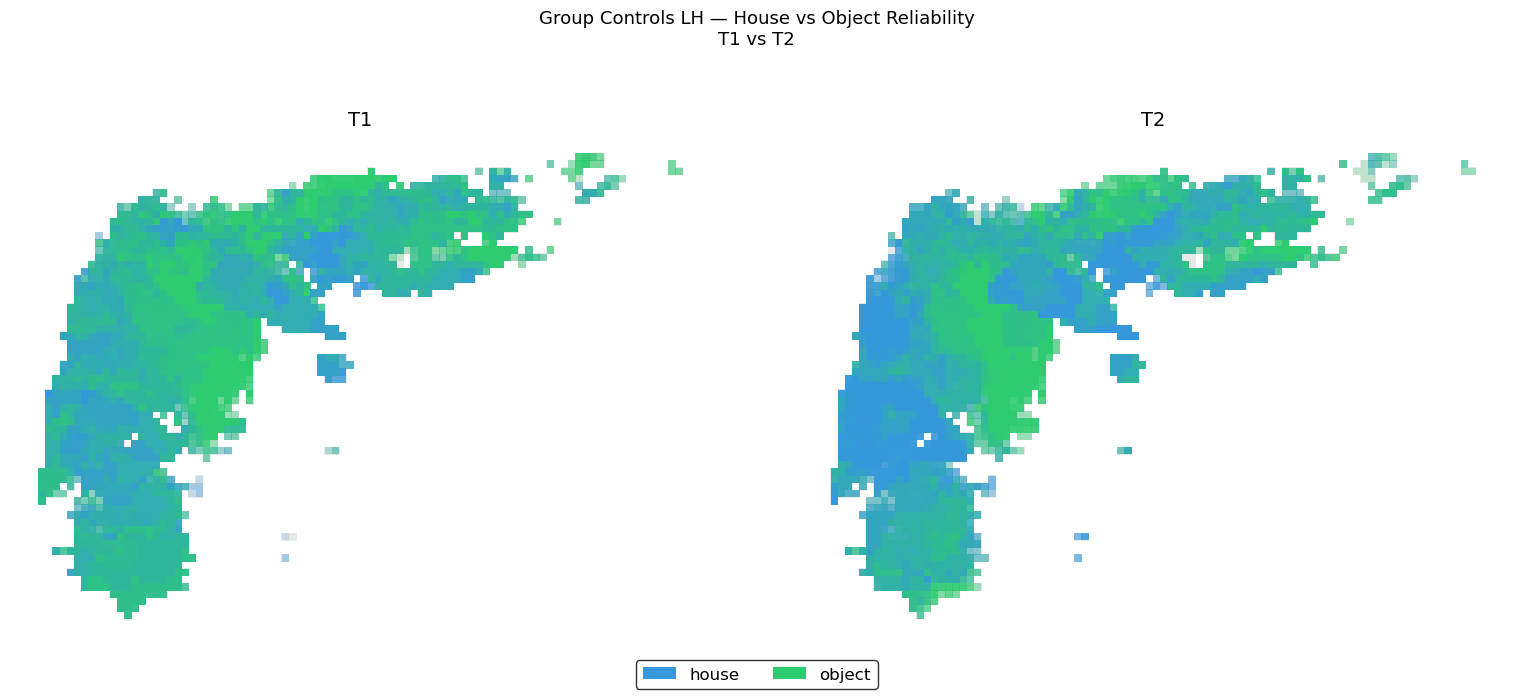

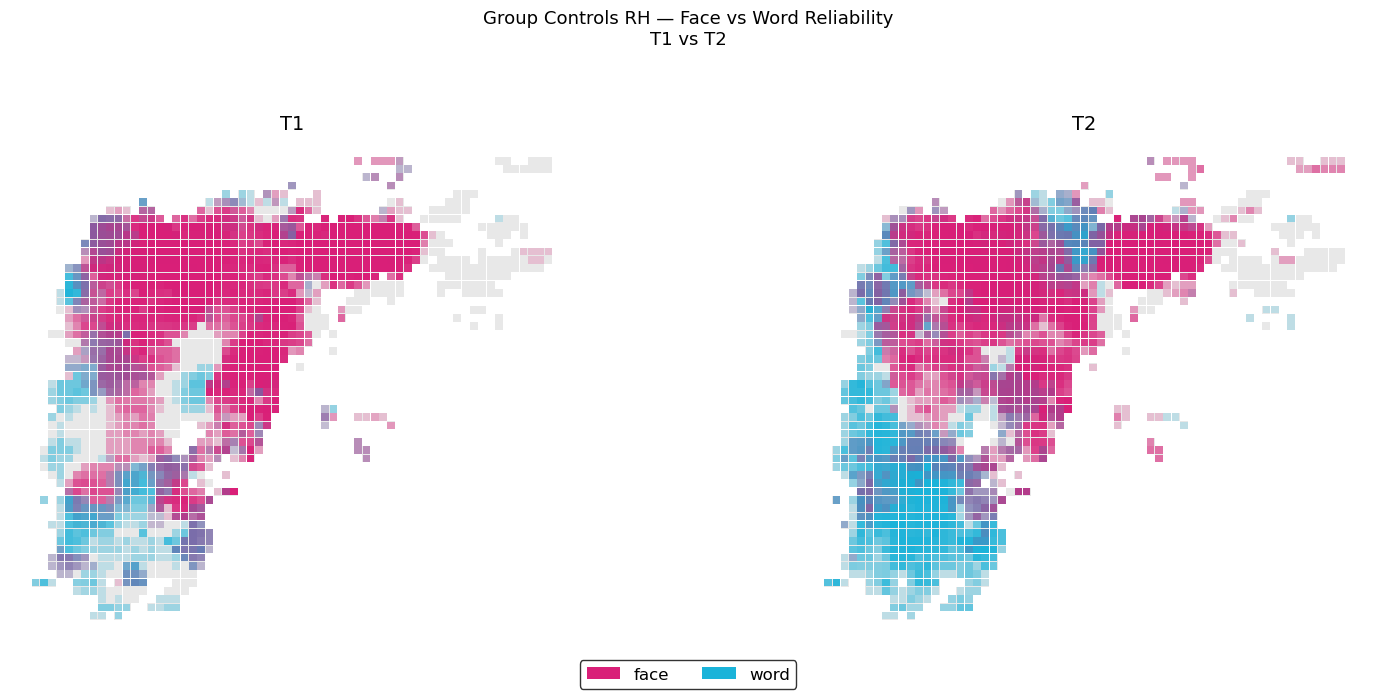

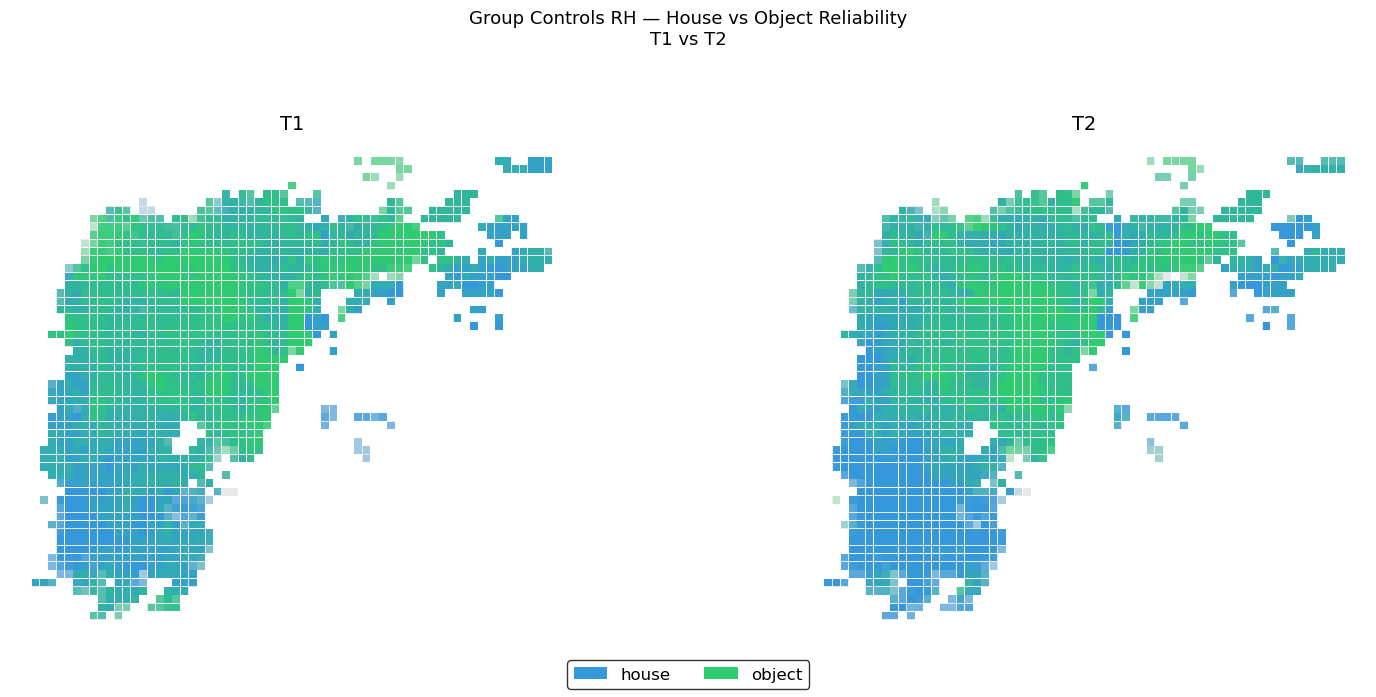

In [30]:
def plot_group_pairwise_blend(hemi, long_subs, pair=('face', 'word'),
                               min_subjects=5, z_thresh=1.96):
    """Blended map for just two categories — much cleaner."""
    cat_a, cat_b = pair
    idx_a, idx_b = CATEGORIES.index(cat_a), CATEGORIES.index(cat_b)

    result_t1 = build_group_votes(long_subs, hemi, session_idx=0, z_thresh=z_thresh)
    result_t2 = build_group_votes(long_subs, hemi, session_idx=-1, z_thresh=z_thresh)

    if result_t1 is None or result_t2 is None:
        print(f"  Insufficient data for {hemi}H")
        return

    votes_t1, count_t1, _, _ = result_t1
    votes_t2, count_t2, _, _ = result_t2

    joint_mask = (count_t1 >= min_subjects) & (count_t2 >= min_subjects)
    coords = np.array(np.where(joint_mask)).T
    if coords.shape[0] == 0:
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax, (votes, count, label) in zip(axes, [
        (votes_t1, count_t1, 'T1'), (votes_t2, count_t2, 'T2')
    ]):
        n = count[joint_mask]
        va = np.zeros_like(n, dtype=float)
        vb = np.zeros_like(n, dtype=float)
        valid = n > 0
        va[valid] = votes[cat_a][joint_mask][valid] / n[valid]
        vb[valid] = votes[cat_b][joint_mask][valid] / n[valid]

        # Gray background
        ax.scatter(coords[:, 1], coords[:, 2], c='#e8e8e8', s=POINT_SIZE,
                   marker='s', linewidths=0, rasterized=True, zorder=1)

        # Only voxels where at least one of the pair has votes
        either = (va > 0) | (vb > 0)
        if either.sum() == 0:
            ax.set_aspect('equal')
            ax.invert_yaxis()
            ax.axis('off')
            continue

        # Blend between two colors based on relative proportion
        total = va[either] + vb[either]
        total[total == 0] = 1
        prop_a = va[either] / total
        prop_b = vb[either] / total

        
        PAIR_RGB = {
            ('face', 'word'):    (np.array([0.85, 0.12, 0.47]), np.array([0.10, 0.70, 0.85])),
            ('house', 'object'): (np.array([0.204, 0.596, 0.859]), np.array([0.180, 0.800, 0.443])),
        }
        rgb_a, rgb_b = PAIR_RGB.get(pair, (CAT_RGB[idx_a], CAT_RGB[idx_b]))
        
        blended = prop_a[:, None] * rgb_a + prop_b[:, None] * rgb_b

        # Alpha by total votes for this pair (how relevant is this voxel)
        alpha = np.clip(total / 1.0, 0.2, 1.0)

        colors = np.zeros((either.sum(), 4))
        colors[:, 0:3] = blended
        colors[:, 3] = alpha

        ax.scatter(coords[either, 1], coords[either, 2], c=colors, s=POINT_SIZE,
                   marker='s', linewidths=0, rasterized=True, zorder=2)
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.axis('off')
        ax.set_title(label, fontsize=14)
    
    
    PAIR_RGB = {
        ('face', 'word'):    (np.array([0.85, 0.12, 0.47]), np.array([0.10, 0.70, 0.85])),
        ('house', 'object'): (np.array([0.204, 0.596, 0.859]), np.array([0.180, 0.800, 0.443])),
    }
    leg_a, leg_b = PAIR_RGB.get(pair, (CAT_RGB[idx_a], CAT_RGB[idx_b]))
    legend_patches = [Patch(facecolor=leg_a, label=cat_a),
                      Patch(facecolor=leg_b, label=cat_b)]
    
    
    
    fig.legend(handles=legend_patches, loc='lower center', ncol=2, fontsize=12,
               frameon=True, edgecolor='black')

    hemi_label = 'LH' if hemi == 'l' else 'RH'
    plt.suptitle(f'Group Controls {hemi_label} — {cat_a.capitalize()} vs '
                 f'{cat_b.capitalize()} Reliability\n'
                 f'T1 vs T2', fontsize=13)
    plt.tight_layout(rect=[0, 0.06, 1, 0.90])
    plt.savefig(os.path.join(processed_dir, 'group_results',
                f'group_ctrl_{hemi}h_{cat_a}v{cat_b}_{ALLEGIANCE_COPE_SET}.png'),
                dpi=200, bbox_inches='tight')
    plt.show()


# ── Run ──────────────────────────────────────────────────────────────────────

print("Pairwise reliability blends...")
for hemi in ['l', 'r']:
    plot_group_pairwise_blend(hemi, long_subs, pair=('face', 'word'))
    plot_group_pairwise_blend(hemi, long_subs, pair=('house', 'object'))